### Prior elicitation 

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import default_rng
import os
import arviz as az

# Import functions
from cmdstanpy import CmdStanModel
from tensorflow_probability.substrates import numpy as tfp
tfd = tfp.distributions


import cmdstanpy
import os
from pathlib import Path

import os, sys
from pathlib import Path
def set_project_root():
        
    # Find and navigate to Progetto_Bayesian_Statistics
    current = Path.cwd()

    # Check if we're already there
    if current.name == 'Progetto_Bayesian_Statistics':
        print(f"Already in project root: {current}")
    else:
        # Search up to parent directories
        for parent in [current] + list(current.parents):
            if parent.name == 'Progetto_Bayesian_Statistics':
                os.chdir(parent)
                print(f"Changed to: {parent}")
                break
        else:
            raise FileNotFoundError("Progetto_Bayesian_Statistics folder not found")

    # Verify
    assert Path('src').exists(), "src/ folder not found"
    print(f"Current directory: {os.getcwd()}")
    print(f"Contents: {os.listdir()}")


    # Create ./stan folder if does not exists
    STAN_PATH = "./src/stan_models/"
    print(cmdstanpy.cmdstan_path())
    return STAN_PATH

STAN_PATH = set_project_root()
print("cwd:", os.getcwd())
print("first sys.path entries:")
for p in sys.path[:5]:
    print("  ", p)

print("project root guess:", Path().resolve())
print("exists ./src ?", (Path().resolve() / "src").exists())

from src.utils.utils import *

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Changed to: /Users/sararedaelli/Desktop/Progetto_Bayesian_Statistics
Current directory: /Users/sararedaelli/Desktop/Progetto_Bayesian_Statistics
Contents: ['configs_table.txt', 'materials', '.DS_Store', 'requirements.txt', 'README.md', 'results', '.gitignore', 'requirements.bk.txt', 'table.txt', '.git', 'results1', 'data', 'src']
/Users/sararedaelli/.cmdstan/cmdstan-2.37.0
cwd: /Users/sararedaelli/Desktop/Progetto_Bayesian_Statistics
first sys.path entries:
   /Library/Frameworks/Python.framework/Versions/3.13/lib/python313.zip
   /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13
   /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/lib-dynload
   
   /Users/sararedaelli/Library/Python/3.13/lib/python/site-packages
project root guess: /Users/sararedaelli/Desktop/Progetto_Bayesian_Statistics
exists ./src ? True


In [2]:
data, data_donors = transform_data()
glm_data, X_D = get_glm_data(data, data_donors)

[1 2 3 4 5 6 7 8]
[1 2 3 4 5 6 7 8]


/Users/sararedaelli/Desktop/Progetto_Bayesian_Statistics/src/utils/utils.py:70: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Control'] = data['Control'].replace({'Yes': 1, 'No': 0})


In [3]:
model_names = model_names = [
    ("sr_invgamma.stan", {"tau_sq_a":3, "tau_sq_b":0.18, "sigma_beta_sq_a":3, "sigma_beta_sq_b":0.18, "mu_alpha_0":0, "sigma_alpha_0":5}),
    ("sr_invgamma.stan", {"tau_sq_a":3, "tau_sq_b":0.18, "sigma_beta_sq_a":3, "sigma_beta_sq_b":0.18, "mu_alpha_0":0, "sigma_alpha_0":10}),


    ("sr_invgamma.stan", {"tau_sq_a":3, "tau_sq_b":0.72, "sigma_beta_sq_a":3, "sigma_beta_sq_b":0.72, "mu_alpha_0":0, "sigma_alpha_0":5}),
    ("sr_invgamma.stan", {"tau_sq_a":3, "tau_sq_b":0.72, "sigma_beta_sq_a":3, "sigma_beta_sq_b":0.72, "mu_alpha_0":0, "sigma_alpha_0":10}),


    ("sr_invgamma.stan", {"tau_sq_a":3, "tau_sq_b":2.0, "sigma_beta_sq_a":3, "sigma_beta_sq_b":2.0, "mu_alpha_0":0, "sigma_alpha_0":5}),
    ("sr_invgamma.stan", {"tau_sq_a":3, "tau_sq_b":2.0, "sigma_beta_sq_a":3, "sigma_beta_sq_b":2.0, "mu_alpha_0":0, "sigma_alpha_0":10}),


    ("sr_invgamma.stan", {"tau_sq_a":3, "tau_sq_b":0.08, "sigma_beta_sq_a":3, "sigma_beta_sq_b":0.08, "mu_alpha_0":0, "sigma_alpha_0":5}),
    ("sr_invgamma.stan", {"tau_sq_a":3, "tau_sq_b":0.08, "sigma_beta_sq_a":3, "sigma_beta_sq_b":0.08, "mu_alpha_0":0, "sigma_alpha_0":10}),


    ("sr_invgamma.stan", {"tau_sq_a":3, "tau_sq_b":4.5, "sigma_beta_sq_a":3, "sigma_beta_sq_b":4.5, "mu_alpha_0":0, "sigma_alpha_0":5}),
    ("sr_invgamma.stan", {"tau_sq_a":3, "tau_sq_b":4.5, "sigma_beta_sq_a":3, "sigma_beta_sq_b":4.5, "mu_alpha_0":0, "sigma_alpha_0":10}),


    ("sr_invgamma.stan", {"tau_sq_a":3, "tau_sq_b":0.18, "sigma_beta_sq_a":3, "sigma_beta_sq_b":2.0, "mu_alpha_0":0, "sigma_alpha_0":5}),
    ("sr_invgamma.stan", {"tau_sq_a":3, "tau_sq_b":0.18, "sigma_beta_sq_a":3, "sigma_beta_sq_b":2.0, "mu_alpha_0":0, "sigma_alpha_0":10}),


    ("sr_invgamma.stan", {"tau_sq_a":3, "tau_sq_b":2.0, "sigma_beta_sq_a":3, "sigma_beta_sq_b":0.18, "mu_alpha_0":0, "sigma_alpha_0":5}),
    ("sr_invgamma.stan", {"tau_sq_a":3, "tau_sq_b":2.0, "sigma_beta_sq_a":3, "sigma_beta_sq_b":0.18, "mu_alpha_0":0, "sigma_alpha_0":10}),


    ("sr_invgamma.stan", {"tau_sq_a":2, "tau_sq_b":0.09, "sigma_beta_sq_a":2, "sigma_beta_sq_b":0.09, "mu_alpha_0":0, "sigma_alpha_0":5}),
    ("sr_invgamma.stan", {"tau_sq_a":2, "tau_sq_b":0.09, "sigma_beta_sq_a":2, "sigma_beta_sq_b":0.09, "mu_alpha_0":0, "sigma_alpha_0":10}),
    ("sr_invgamma.stan", {"tau_sq_a":2, "tau_sq_b":1.0,  "sigma_beta_sq_a":2, "sigma_beta_sq_b":1.0,  "mu_alpha_0":0, "sigma_alpha_0":5}),
    ("sr_invgamma.stan", {"tau_sq_a":2, "tau_sq_b":1.0,  "sigma_beta_sq_a":2, "sigma_beta_sq_b":1.0,  "mu_alpha_0":0, "sigma_alpha_0":10}),
    
    # ("sr_tstudent.stan", {"student_df":3,"student_scale":0.5,"mu_alpha_0":0,"sigma_alpha_0":1}),
    # ("sr_tstudent.stan", {"student_df":3,"student_scale":0.5,"mu_alpha_0":0,"sigma_alpha_0":10}),
    # ("sr_tstudent.stan", {"student_df":3,"student_scale":0.5,"mu_alpha_0":0,"sigma_alpha_0":10}),
    # ("sr_halfnormal.stan", {"sigma_b":0.5,"mu_alpha_0":0,"sigma_alpha_0":1}),
    # ("sr_halfnormal.stan", {"sigma_b":0.5,"mu_alpha_0":0,"sigma_alpha_0":10}),
    # ("sr_halfnormal.stan", {"sigma_b":1,"mu_alpha_0":0,"sigma_alpha_0":10})
]

models = {}
for key in model_names:
    print(f"Compiling model: {key}")
    glm = CmdStanModel(stan_file=f"{STAN_PATH}/{key[0]}")
    for x in X_D:
        if x == "X2":
            print(f"Fitting model: {key} with {x} (skipped)")
            continue
        models[(key[0], tuple(key[1].items()), x)] = {"model": glm, "X": X_D[x]}
        new_data = glm_data.copy()
        new_data.update({"X": X_D[x], "p": X_D[x].shape[1]})
        new_data.update(key[1])
        models[(key[0], tuple(key[1].items()), x)]["data"] = new_data

Compiling model: ('sr_invgamma.stan', {'tau_sq_a': 3, 'tau_sq_b': 0.18, 'sigma_beta_sq_a': 3, 'sigma_beta_sq_b': 0.18, 'mu_alpha_0': 0, 'sigma_alpha_0': 5})
Fitting model: ('sr_invgamma.stan', {'tau_sq_a': 3, 'tau_sq_b': 0.18, 'sigma_beta_sq_a': 3, 'sigma_beta_sq_b': 0.18, 'mu_alpha_0': 0, 'sigma_alpha_0': 5}) with X2 (skipped)
Compiling model: ('sr_invgamma.stan', {'tau_sq_a': 3, 'tau_sq_b': 0.18, 'sigma_beta_sq_a': 3, 'sigma_beta_sq_b': 0.18, 'mu_alpha_0': 0, 'sigma_alpha_0': 10})
Fitting model: ('sr_invgamma.stan', {'tau_sq_a': 3, 'tau_sq_b': 0.18, 'sigma_beta_sq_a': 3, 'sigma_beta_sq_b': 0.18, 'mu_alpha_0': 0, 'sigma_alpha_0': 10}) with X2 (skipped)
Compiling model: ('sr_invgamma.stan', {'tau_sq_a': 3, 'tau_sq_b': 0.72, 'sigma_beta_sq_a': 3, 'sigma_beta_sq_b': 0.72, 'mu_alpha_0': 0, 'sigma_alpha_0': 5})
Fitting model: ('sr_invgamma.stan', {'tau_sq_a': 3, 'tau_sq_b': 0.72, 'sigma_beta_sq_a': 3, 'sigma_beta_sq_b': 0.72, 'mu_alpha_0': 0, 'sigma_alpha_0': 5}) with X2 (skipped)
Compilin

In [7]:
len(models)

36

In [5]:
from concurrent.futures import ThreadPoolExecutor, as_completed

def sample_model(key, model_config, sample_config):
    glm_fit = model_config["model"].sample(
        data=model_config["data"], 
        **sample_config
    )
    return key, glm_fit


sample_config = {
    "chains": 4,  
    "parallel_chains": 4,
    "iter_warmup": 1200, 
    "iter_sampling": 5500,
    "show_console": True,
    "adapt_delta": 0.99,  # increase from 0.8
    "max_treedepth": 12, 
}



In [ ]:


max_workers = 1
with ThreadPoolExecutor(max_workers=max_workers) as executor:
    futures = {
        executor.submit(sample_model, k, v, sample_config): k 
        for k, v in models.items()
    }
    for future in as_completed(futures):
        try:
            key, fit = future.result()
        except Exception as e:
            print(f"Error fitting model {futures[future]}: {e}")
            continue
        models[key]["fit"] = fit
        models[key]["az"] = az.from_cmdstanpy(fit)
        poi_glm_data = models[key]["az"]
        #print(f"Divergences {key}: {np.sum(poi_glm_data.sample_stats.diverging.values)}")
    
    # Create filename from key tuple
        filename = f"{'_'.join(str(k) for k in key)}.nc"
        az.to_netcdf(poi_glm_data, f"./results/sr_prolic/{filename}")
        print(f"✓ Completed: {key}")

print("\n✓ All models fitted")

01:47:14 - cmdstanpy - INFO - Chain [1] start processing
01:47:14 - cmdstanpy - INFO - Chain [2] start processing
01:47:14 - cmdstanpy - INFO - Chain [3] start processing
01:47:14 - cmdstanpy - INFO - Chain [4] start processing


Chain [1] method = sample (Default)
Chain [1] sample
Chain [1] num_samples = 5500
Chain [1] num_warmup = 1200
Chain [1] save_warmup = false (Default)
Chain [1] thin = 1 (Default)
Chain [1] adapt
Chain [1] engaged = true (Default)
Chain [1] gamma = 0.05 (Default)
Chain [1] delta = 0.99
Chain [1] kappa = 0.75 (Default)
Chain [1] t0 = 10 (Default)
Chain [1] init_buffer = 75 (Default)
Chain [1] term_buffer = 50 (Default)
Chain [1] window = 25 (Default)
Chain [1] save_metric = false (Default)
Chain [1] algorithm = hmc (Default)
Chain [1] hmc
Chain [1] engine = nuts (Default)
Chain [1] nuts
Chain [1] max_depth = 12
Chain [1] metric = diag_e (Default)
Chain [1] metric_file =  (Default)
Chain [1] stepsize = 1 (Default)
Chain [1] stepsize_jitter = 0 (Default)
Chain [1] num_chains = 1 (Default)
Chain [1] id = 1 (Default)
Chain [1] data
Chain [1] file = /tmp/tmpmeg4zozx/djffzww9.json
Chain [1] init = 2 (Default)
Chain [1] random
Chain [1] seed = 65566
Chain [1] output
Chain [1] file = /tmp/tmpmeg

01:48:18 - cmdstanpy - INFO - Chain [3] done processing


Chain [3] Iteration: 6700 / 6700 [100%]  (Sampling)
Chain [3] 
Chain [3] Elapsed Time: 17.204 seconds (Warm-up)
Chain [3] 43.673 seconds (Sampling)
Chain [3] 60.877 seconds (Total)
Chain [3] 
Chain [3] 
Chain [4] Iteration: 5400 / 6700 [ 80%]  (Sampling)
Chain [1] Iteration: 6000 / 6700 [ 89%]  (Sampling)
Chain [2] Iteration: 6300 / 6700 [ 94%]  (Sampling)
Chain [4] Iteration: 5500 / 6700 [ 82%]  (Sampling)
Chain [2] Iteration: 6400 / 6700 [ 95%]  (Sampling)
Chain [1] Iteration: 6100 / 6700 [ 91%]  (Sampling)
Chain [4] Iteration: 5600 / 6700 [ 83%]  (Sampling)
Chain [2] Iteration: 6500 / 6700 [ 97%]  (Sampling)
Chain [1] Iteration: 6200 / 6700 [ 92%]  (Sampling)
Chain [4] Iteration: 5700 / 6700 [ 85%]  (Sampling)
Chain [2] Iteration: 6600 / 6700 [ 98%]  (Sampling)
Chain [1] Iteration: 6300 / 6700 [ 94%]  (Sampling)


01:48:22 - cmdstanpy - INFO - Chain [2] done processing


...

Chain [3] Iteration: 6700 / 6700 [100%]  (Sampling)
Chain [3] 
Chain [3] Elapsed Time: 20.564 seconds (Warm-up)
Chain [3] 44.145 seconds (Sampling)
Chain [3] 64.709 seconds (Total)
Chain [3] 
Chain [3] 
Chain [2] Iteration: 6700 / 6700 [100%]  (Sampling)
Chain [2] 
Chain [2] Elapsed Time: 12.204 seconds (Warm-up)
Chain [2] 52.526 seconds (Sampling)
Chain [2] 64.73 seconds (Total)
Chain [2] 
Chain [2] 
Chain [4] Iteration: 4700 / 6700 [ 70%]  (Sampling)
Chain [4] Iteration: 4800 / 6700 [ 71%]  (Sampling)
Chain [4] Iteration: 4900 / 6700 [ 73%]  (Sampling)
Chain [4] Iteration: 5000 / 6700 [ 74%]  (Sampling)
Chain [4] Iteration: 5100 / 6700 [ 76%]  (Sampling)
Chain [4] Iteration: 5200 / 6700 [ 77%]  (Sampling)
Chain [4] Iteration: 5300 / 6700 [ 79%]  (Sampling)
Chain [4] Iteration: 5400 / 6700 [ 80%]  (Sampling)
Chain [4] Iteration: 5500 / 6700 [ 82%]  (Sampling)
Chain [4] Iteration: 5600 / 6700 [ 83%]  (Sampling)
Chain [4] Iteration: 5700 / 6700 [ 85%]  (Sampling)
Chain [4] Iteration: 58

02:02:45 - cmdstanpy - INFO - Chain [4] done processing
02:02:45 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: poisson_lpmf: Rate parameter is -nan, but must be nonnegative! (in 'sr_invgamma.stan', line 48, column 8 to column 45)
Exception: poisson_lpmf: Rate parameter is -nan, but must be nonnegative! (in 'sr_invgamma.stan', line 48, column 8 to column 45)


Chain [4] Iteration: 6700 / 6700 [100%]  (Sampling)
Chain [4] 
Chain [4] Elapsed Time: 15.087 seconds (Warm-up)
Chain [4] 74.814 seconds (Sampling)
Chain [4] 89.901 seconds (Total)
Chain [4] 
Chain [4] 


02:02:46 - cmdstanpy - INFO - Chain [1] start processing
02:02:46 - cmdstanpy - INFO - Chain [2] start processing
02:02:46 - cmdstanpy - INFO - Chain [3] start processing
02:02:46 - cmdstanpy - INFO - Chain [4] start processing


Chain [1] method = sample (Default)
Chain [1] sample
Chain [1] num_samples = 5500
Chain [1] num_warmup = 1200
Chain [1] save_warmup = false (Default)
Chain [1] thin = 1 (Default)
Chain [1] adapt
Chain [1] engaged = true (Default)
Chain [1] gamma = 0.05 (Default)
Chain [1] delta = 0.99
Chain [1] kappa = 0.75 (Default)
Chain [1] t0 = 10 (Default)
Chain [1] init_buffer = 75 (Default)
Chain [1] term_buffer = 50 (Default)
Chain [1] window = 25 (Default)
Chain [1] save_metric = false (Default)
Chain [1] algorithm = hmc (Default)
Chain [1] hmc
Chain [1] engine = nuts (Default)
Chain [1] nuts
Chain [1] max_depth = 12
Chain [1] metric = diag_e (Default)
Chain [1] metric_file =  (Default)
Chain [1] stepsize = 1 (Default)
Chain [1] stepsize_jitter = 0 (Default)
Chain [1] num_chains = 1 (Default)
Chain [1] id = 1 (Default)
Chain [1] data
Chain [1] file = /tmp/tmpmeg4zozx/2kxvkqzt.json
Chain [1] init = 2 (Default)
Chain [1] random
Chain [1] seed = 54197
Chain [1] output
Chain [1] file = /tmp/tmpmeg

In [5]:
import os
remove_keys = []
for key in models:
    filename = f"{'_'.join(str(k) for k in key)}.nc"
    try:
        models[key]["az"] = az.from_netcdf(f"./results/sr_prolic/{filename}")
    except:
        remove_keys.append(key)
        pass




In [6]:
for k in models:
    print(models[k].keys())

dict_keys(['model', 'X', 'data', 'az'])
dict_keys(['model', 'X', 'data', 'az'])
dict_keys(['model', 'X', 'data', 'az'])
dict_keys(['model', 'X', 'data', 'az'])
dict_keys(['model', 'X', 'data', 'az'])
dict_keys(['model', 'X', 'data', 'az'])
dict_keys(['model', 'X', 'data', 'az'])
dict_keys(['model', 'X', 'data', 'az'])
dict_keys(['model', 'X', 'data', 'az'])
dict_keys(['model', 'X', 'data', 'az'])
dict_keys(['model', 'X', 'data', 'az'])
dict_keys(['model', 'X', 'data', 'az'])
dict_keys(['model', 'X', 'data'])
dict_keys(['model', 'X', 'data'])
dict_keys(['model', 'X', 'data'])
dict_keys(['model', 'X', 'data'])
dict_keys(['model', 'X', 'data'])
dict_keys(['model', 'X', 'data'])
dict_keys(['model', 'X', 'data'])
dict_keys(['model', 'X', 'data'])
dict_keys(['model', 'X', 'data'])
dict_keys(['model', 'X', 'data'])
dict_keys(['model', 'X', 'data'])
dict_keys(['model', 'X', 'data'])
dict_keys(['model', 'X', 'data'])
dict_keys(['model', 'X', 'data'])
dict_keys(['model', 'X', 'data'])
dict_keys(

In [8]:
import os

os.makedirs("./results/sr_prolic/", exist_ok=True)

for key in models:
    try:
        poi_glm_data = models[key]["fit"]
        #print(f"Divergences {key}: {np.sum(poi_glm_data.sample_stats.diverging.values)}")
    
    # Create filename from key tuple
        filename = f"{'_'.join(str(k) for k in key)}.nc"
        az.to_netcdf(poi_glm_data, f"./results/sr_prolic/{filename}")
    except KeyError:
        print(f"Model {key} not found in models dictionary")
        continue
    
    # Print divergences
    

Model ('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 0.18), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 0.18), ('mu_alpha_0', 0), ('sigma_alpha_0', 5)), 'X') not found in models dictionary
Model ('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 0.18), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 0.18), ('mu_alpha_0', 0), ('sigma_alpha_0', 5)), 'X2_I') not found in models dictionary
Model ('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 0.18), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 0.18), ('mu_alpha_0', 0), ('sigma_alpha_0', 10)), 'X') not found in models dictionary
Model ('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 0.18), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 0.18), ('mu_alpha_0', 0), ('sigma_alpha_0', 10)), 'X2_I') not found in models dictionary
Model ('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 0.72), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 0.72), ('mu_alpha_0', 0), ('sigma_alpha_0', 5)), 'X') not found in models dictionary
Model ('sr_invgamma.st

In [9]:
for key in models:
    poi_glm_data = models[key]["az"]
    print("divergence of ",key,np.sum(poi_glm_data.sample_stats.diverging))

divergence of  ('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 0.18), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 0.18), ('mu_alpha_0', 0), ('sigma_alpha_0', 5)), 'X') <xarray.DataArray 'diverging' ()> Size: 8B
array(0)
divergence of  ('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 0.18), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 0.18), ('mu_alpha_0', 0), ('sigma_alpha_0', 5)), 'X2_I') <xarray.DataArray 'diverging' ()> Size: 8B
array(0)
divergence of  ('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 0.18), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 0.18), ('mu_alpha_0', 0), ('sigma_alpha_0', 10)), 'X') <xarray.DataArray 'diverging' ()> Size: 8B
array(0)
divergence of  ('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 0.18), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 0.18), ('mu_alpha_0', 0), ('sigma_alpha_0', 10)), 'X2_I') <xarray.DataArray 'diverging' ()> Size: 8B
array(0)
divergence of  ('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 0.72), ('sigma_beta_sq_a', 3)

KeyError: 'az'

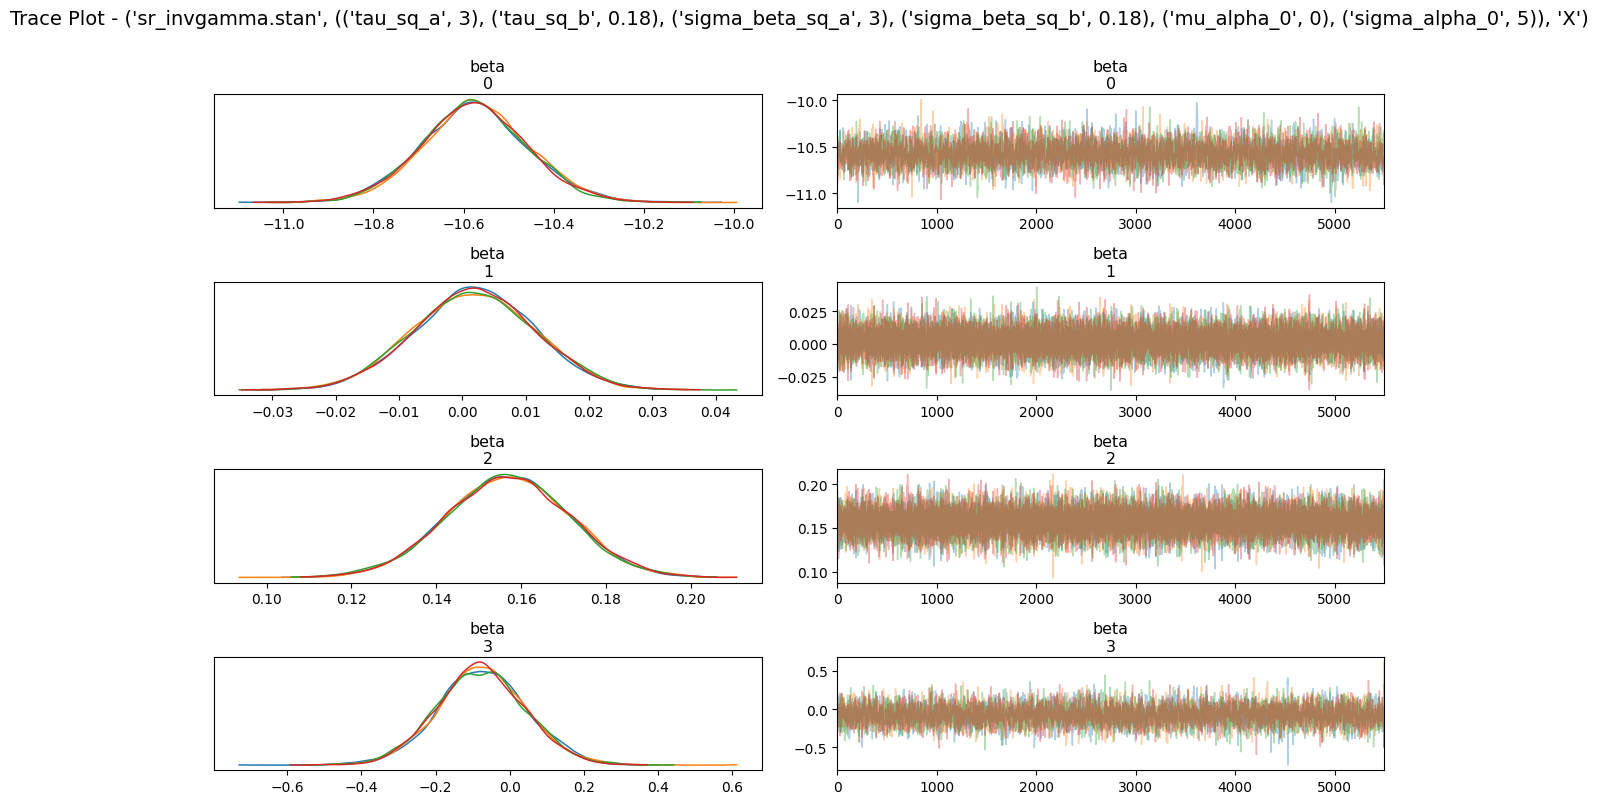

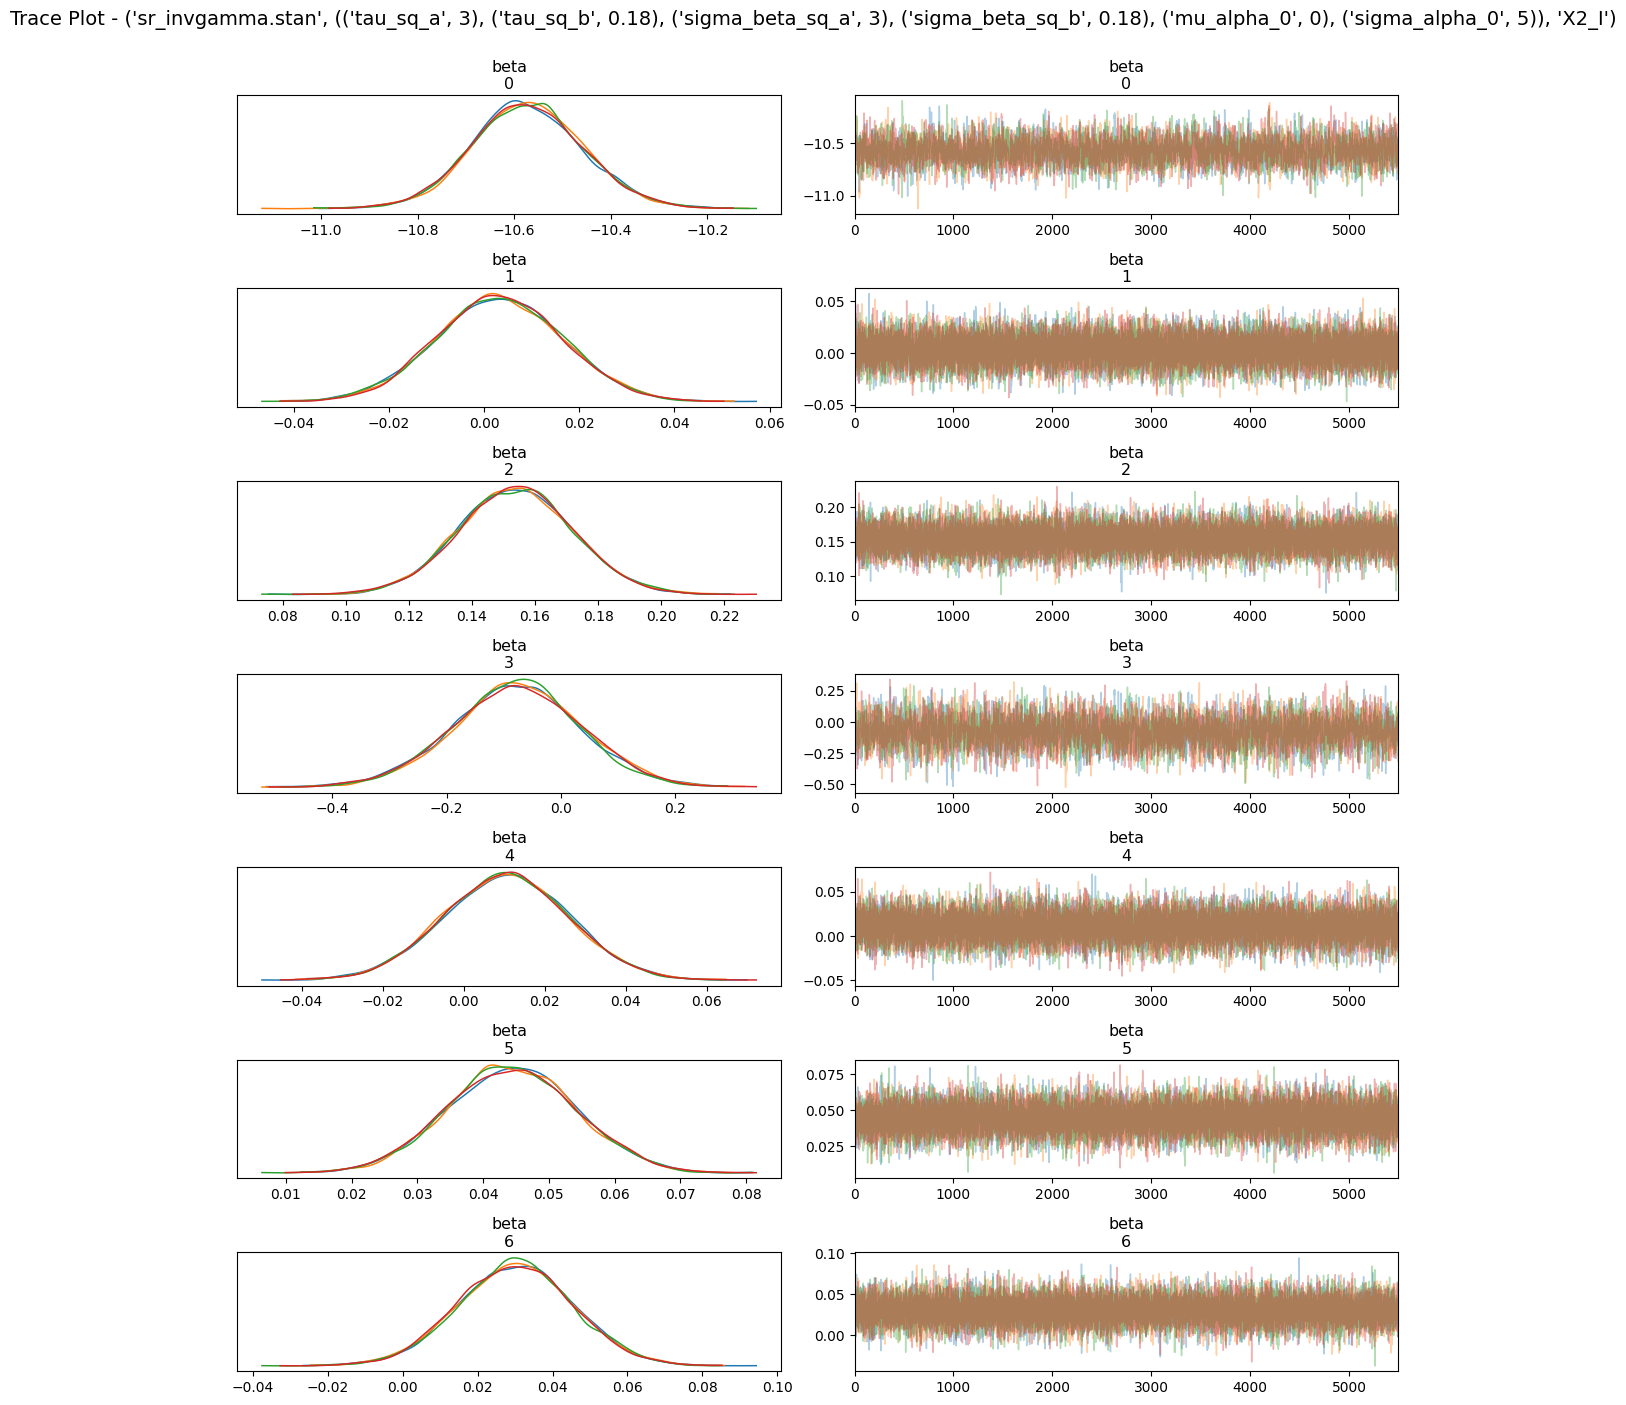

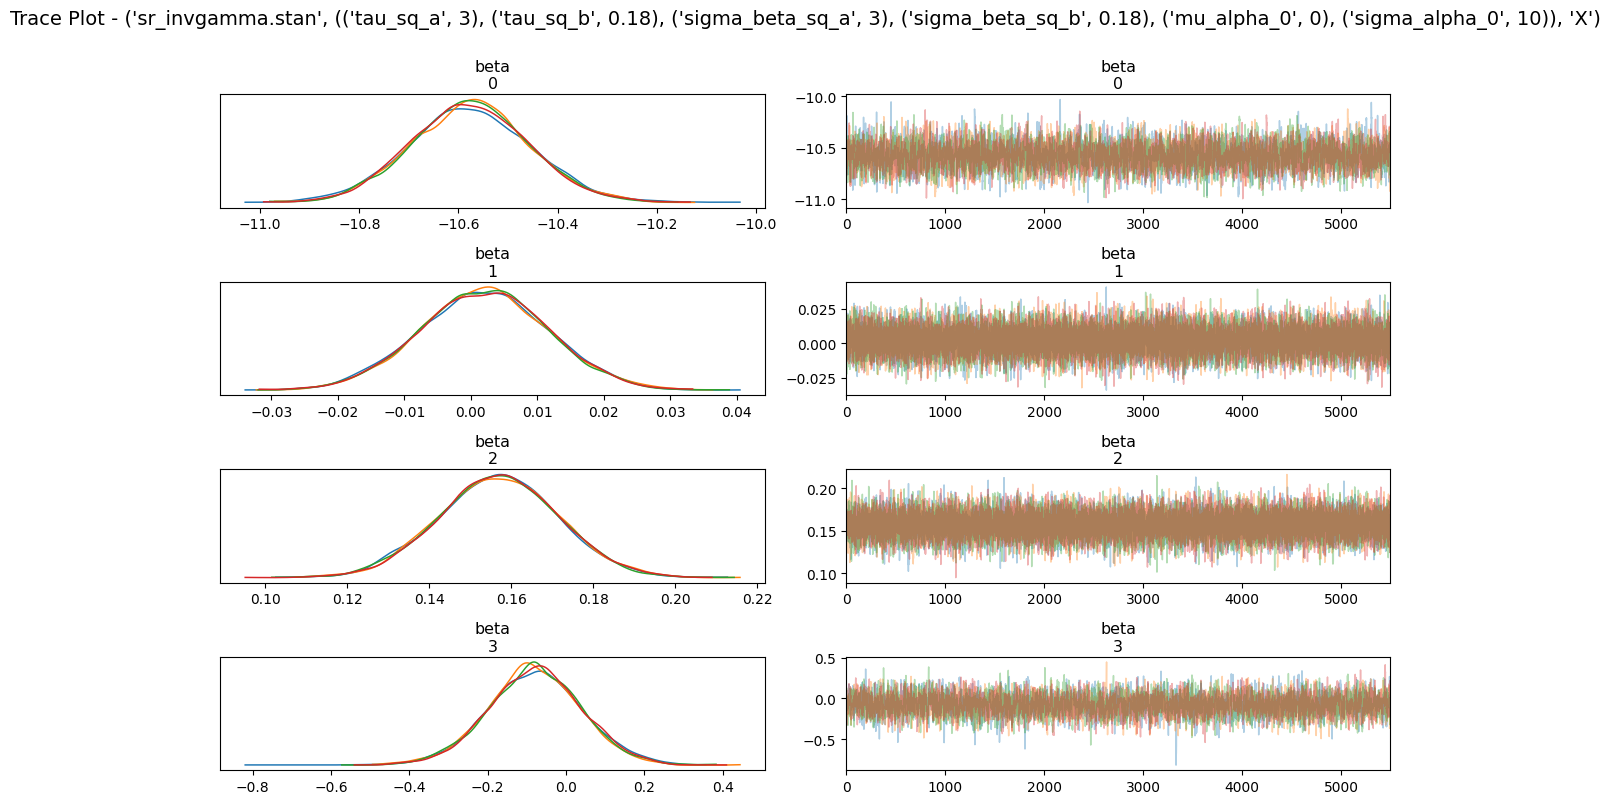

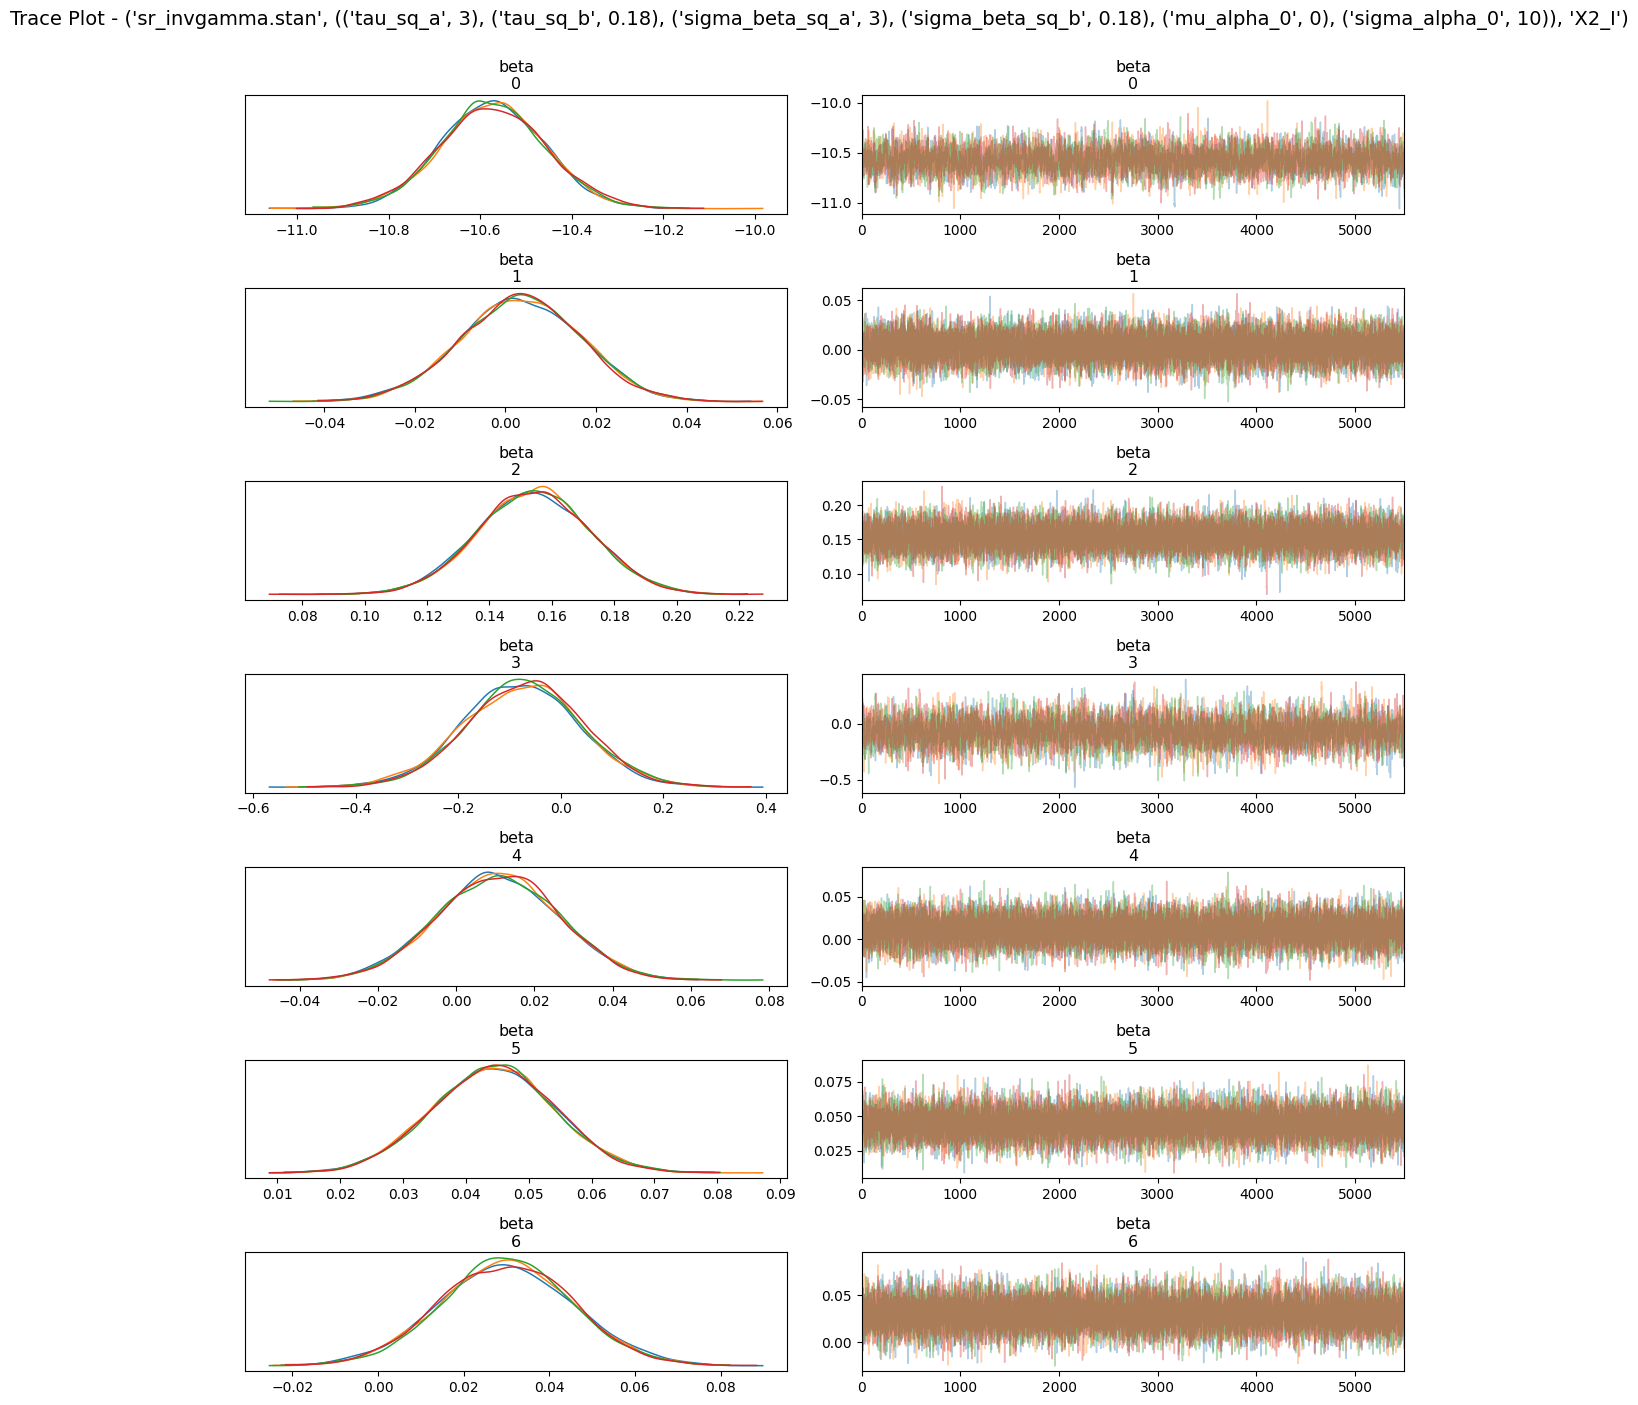

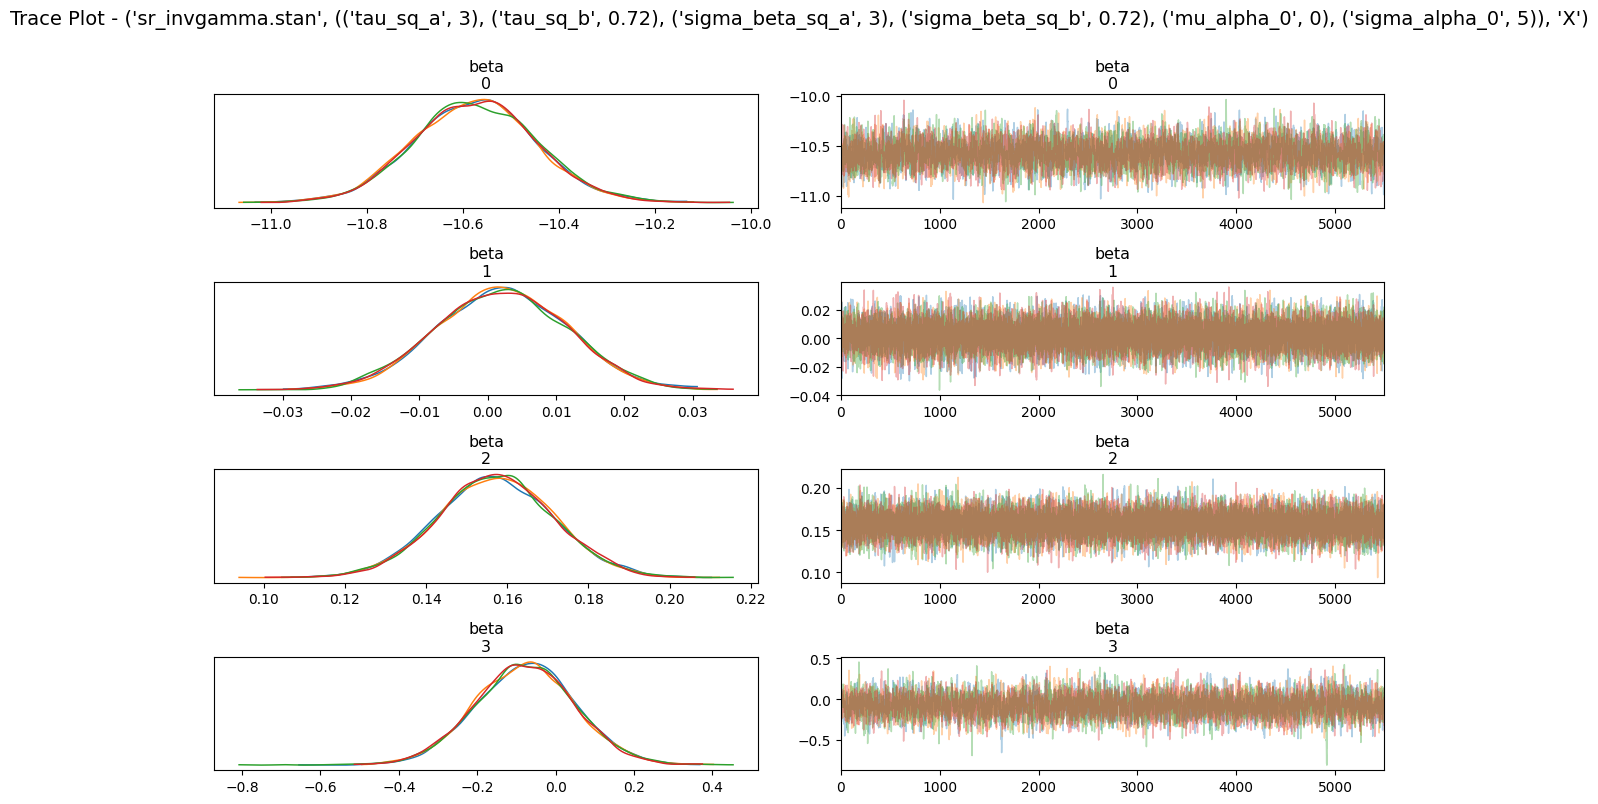

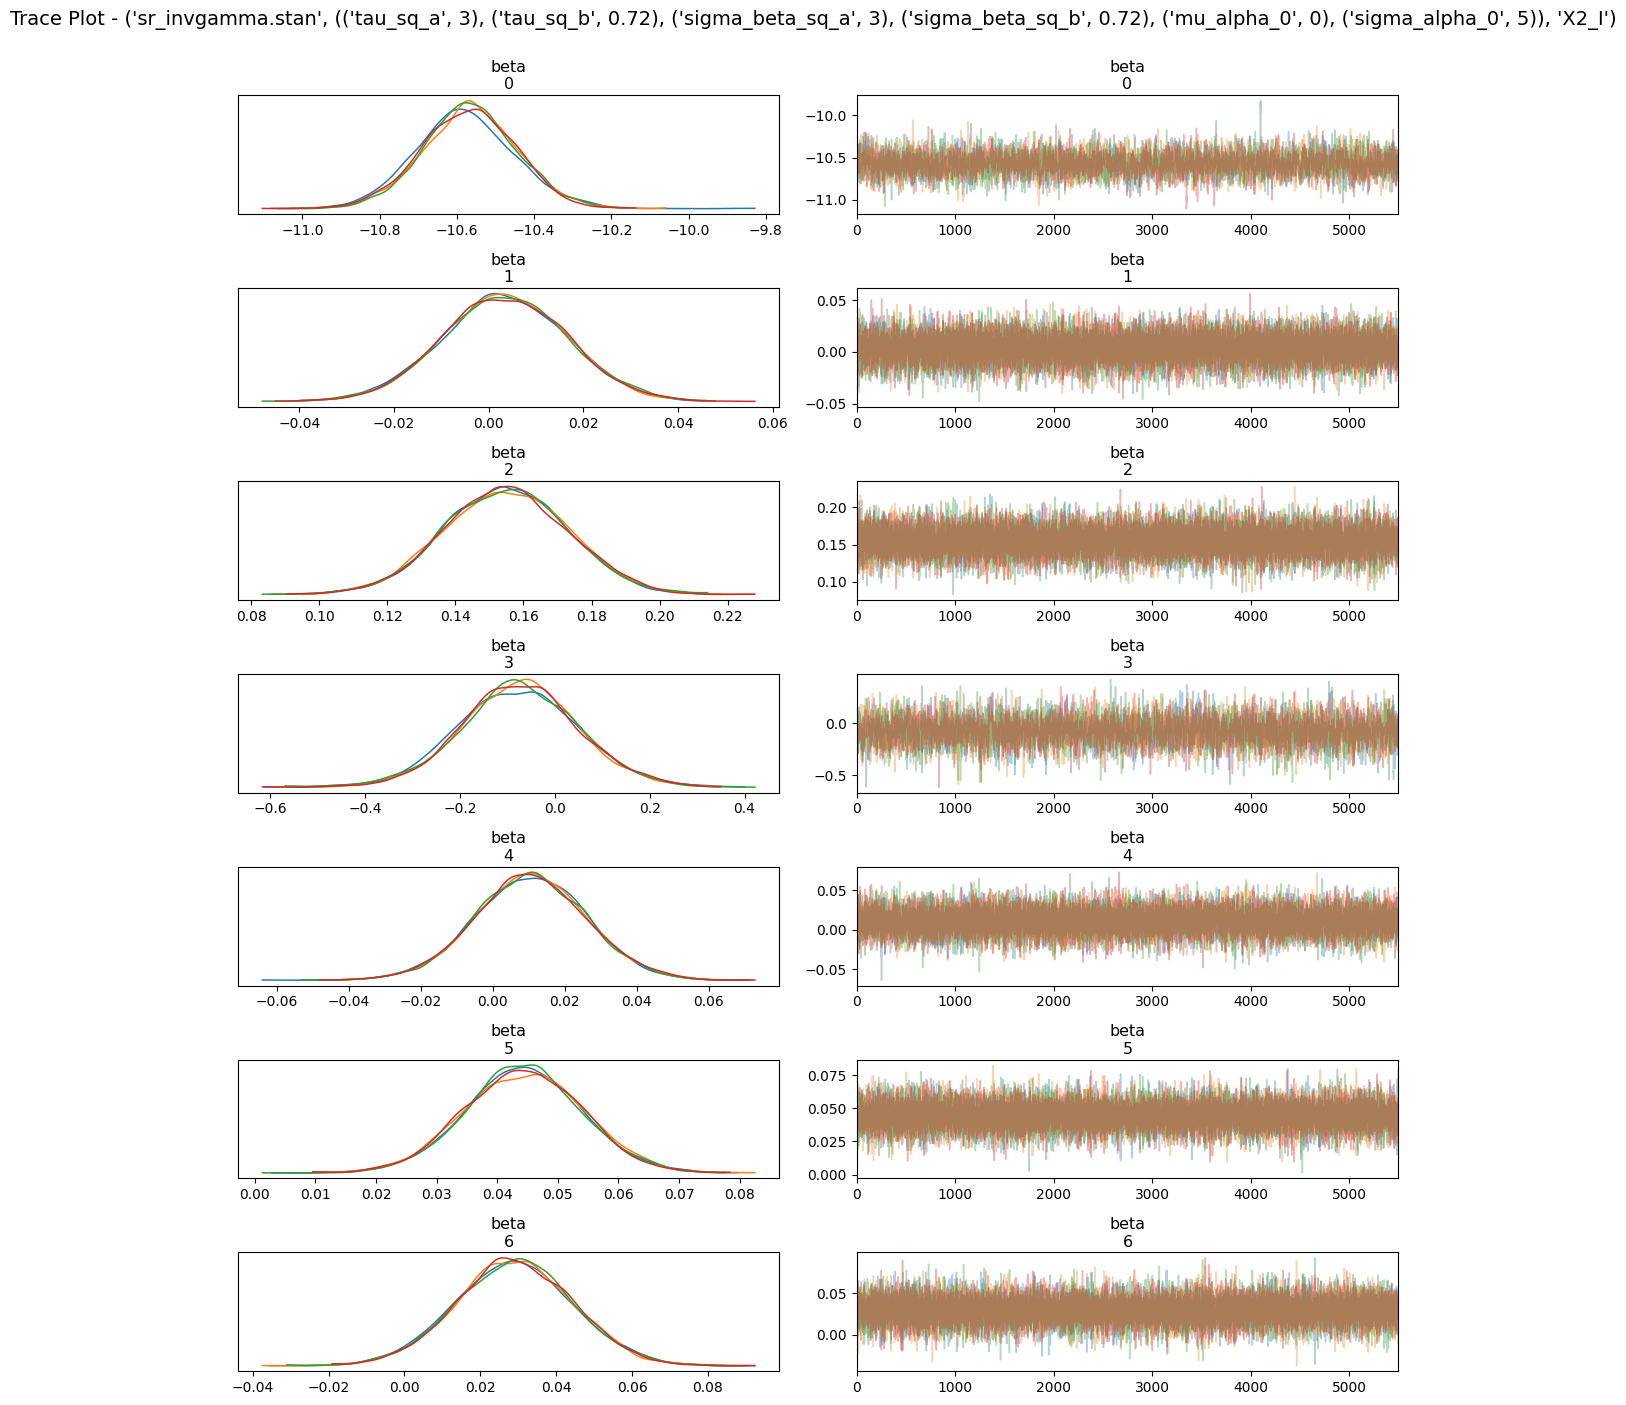

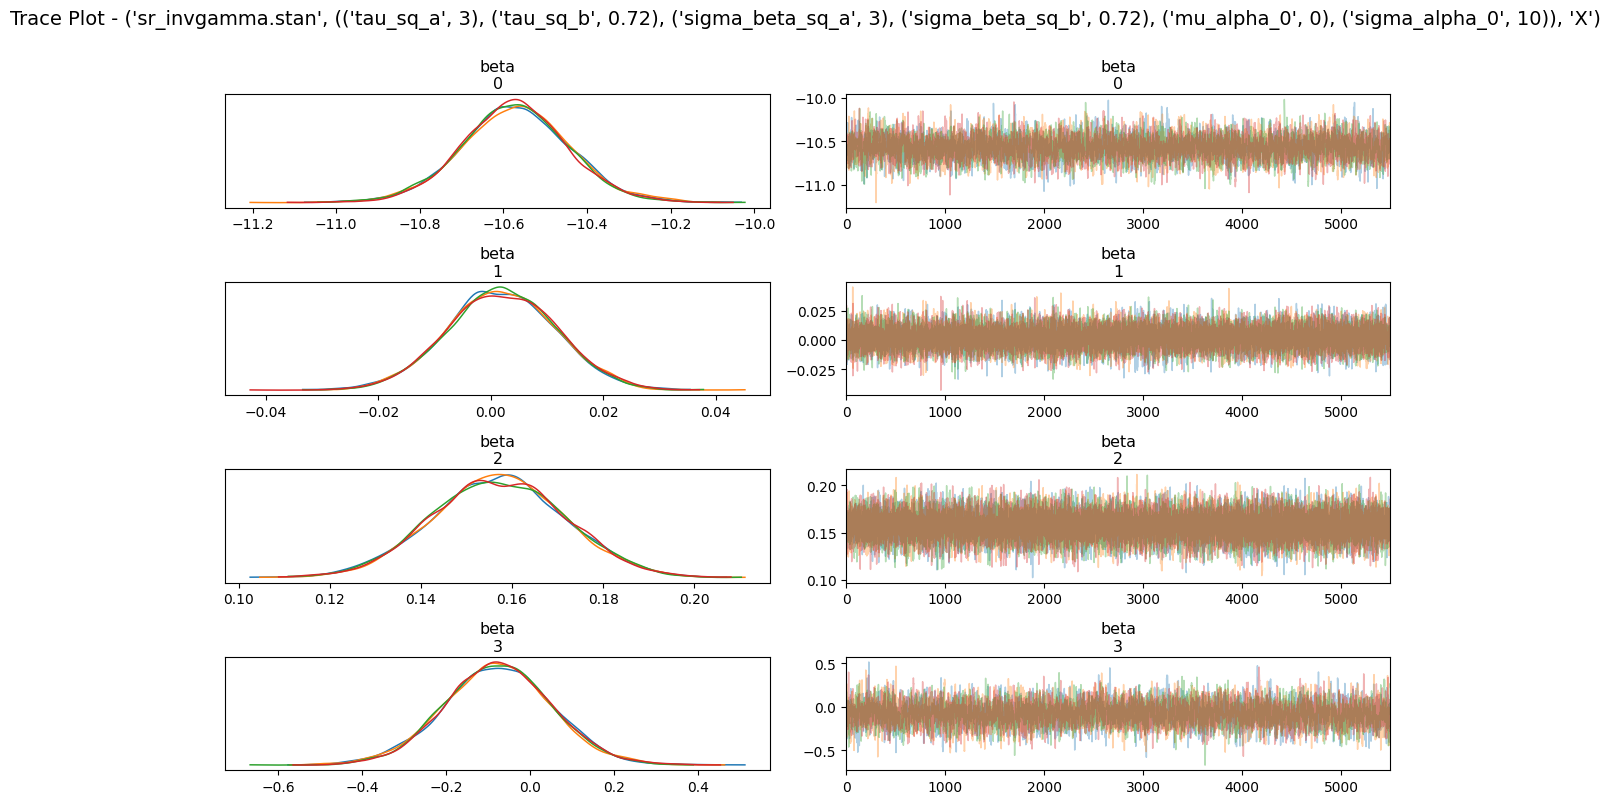

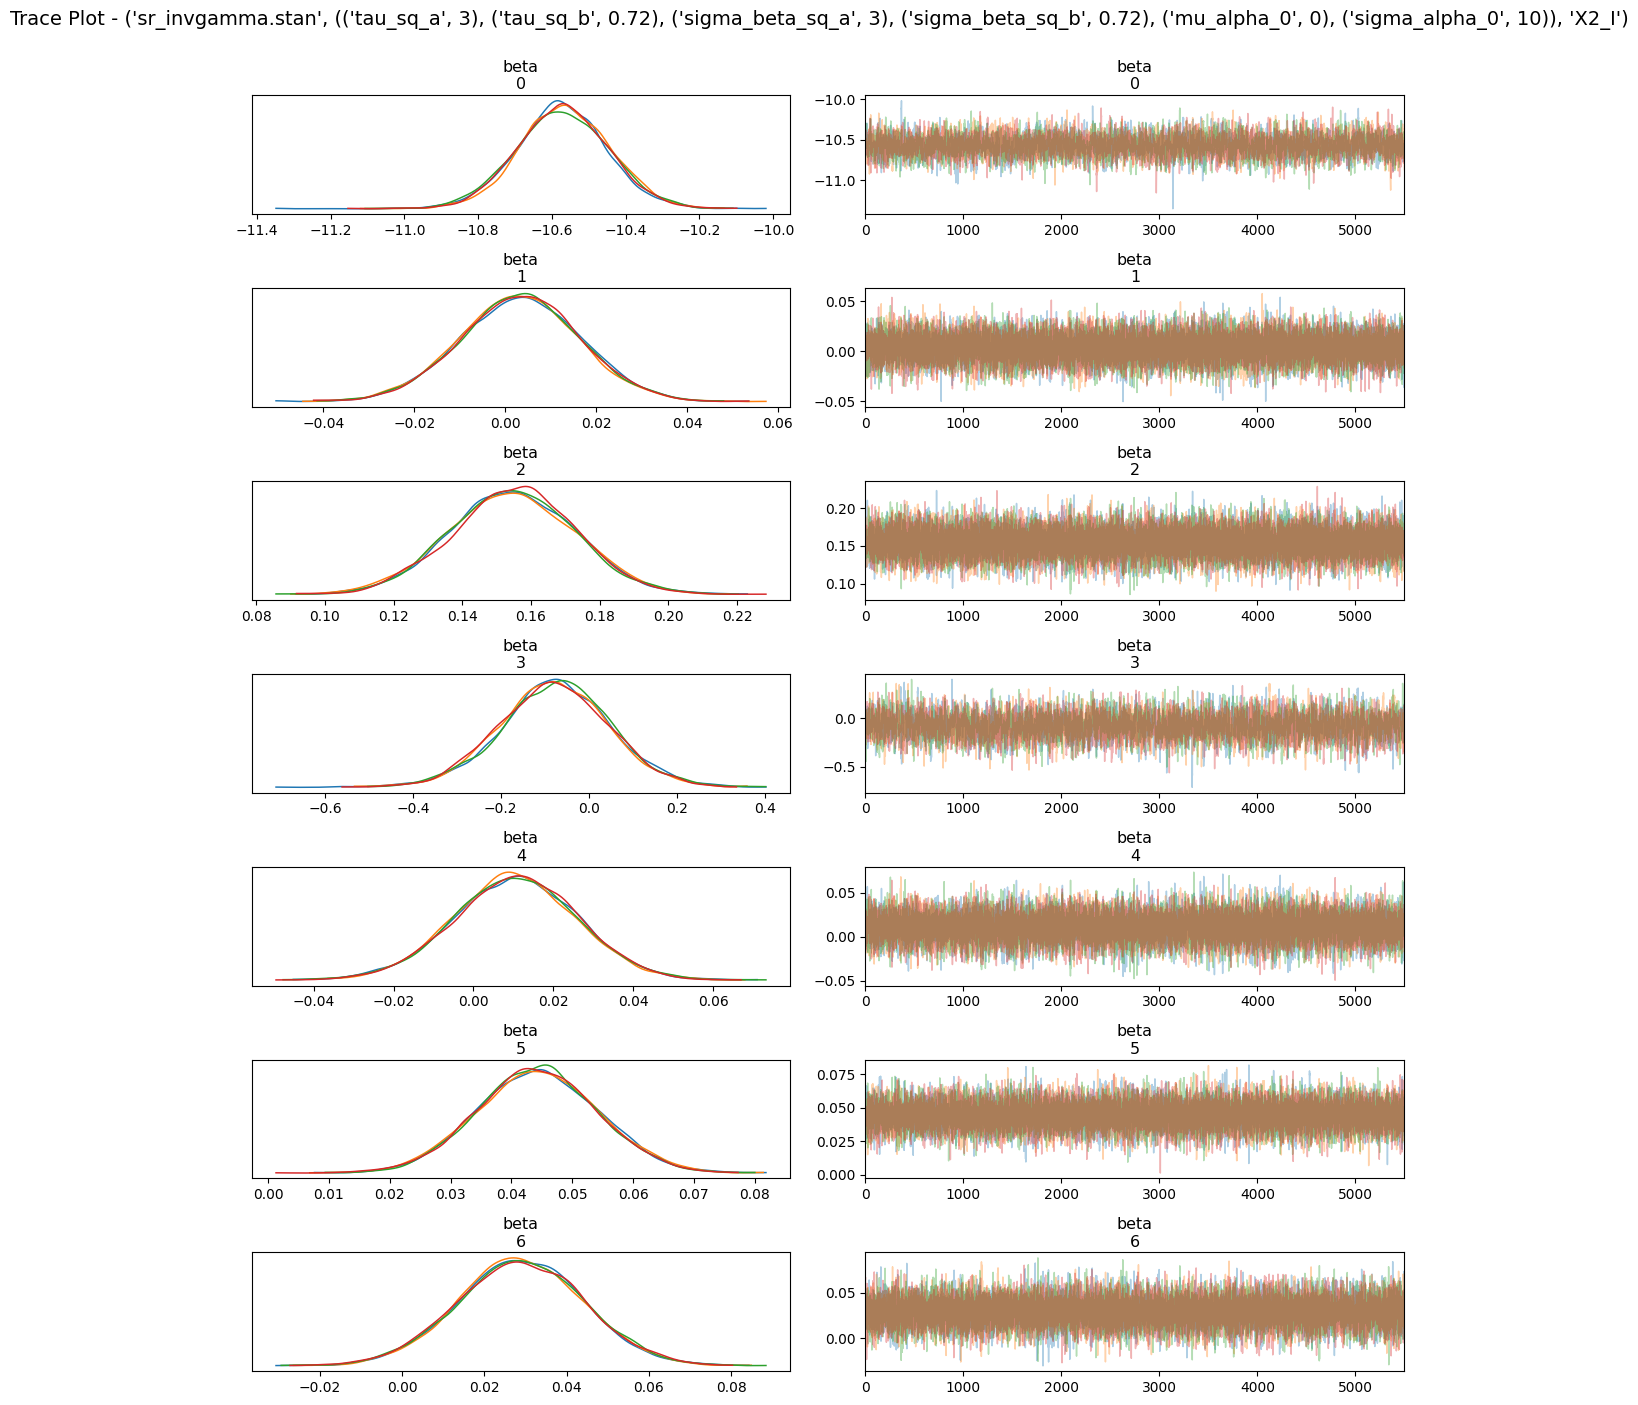

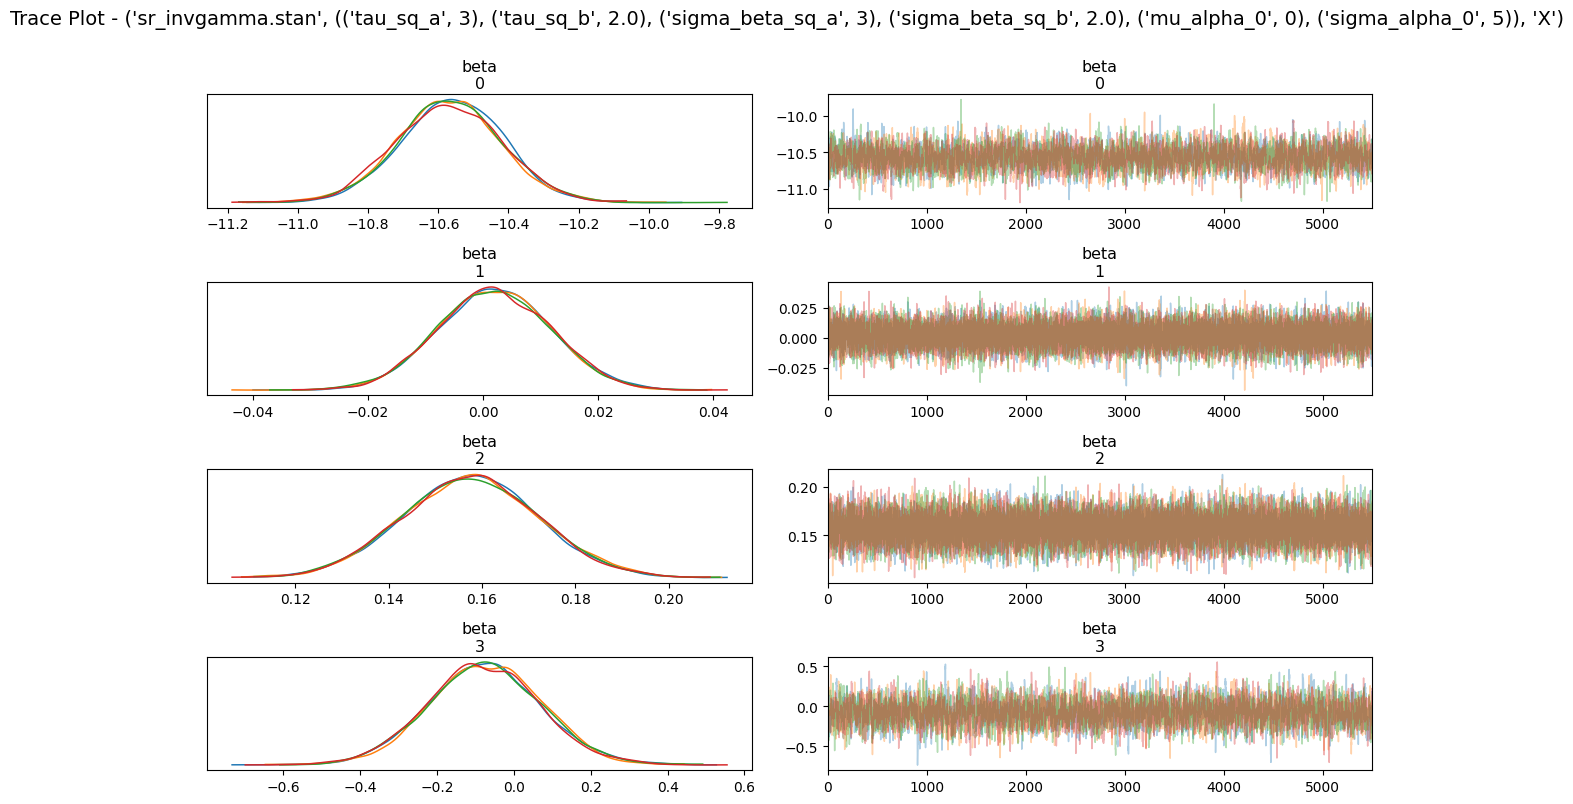

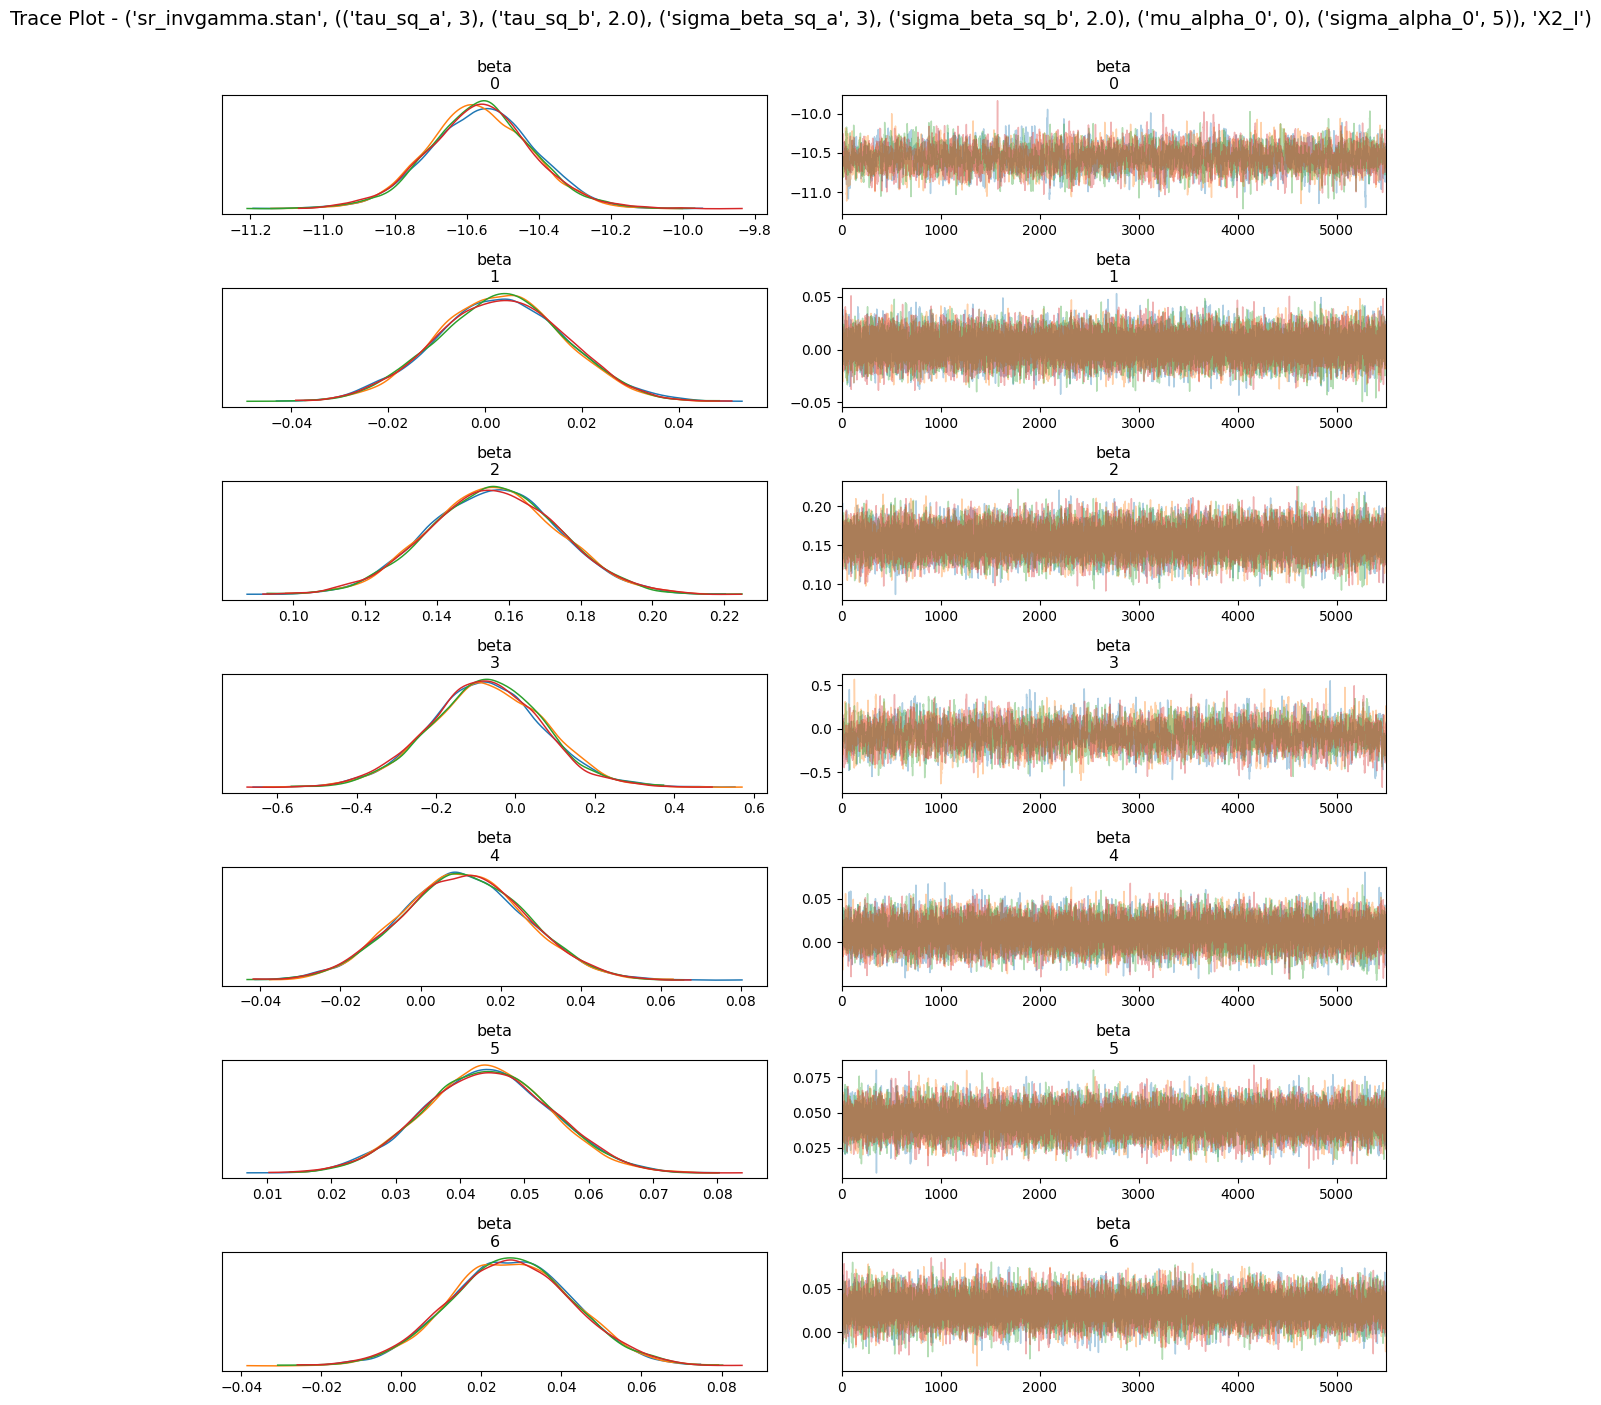

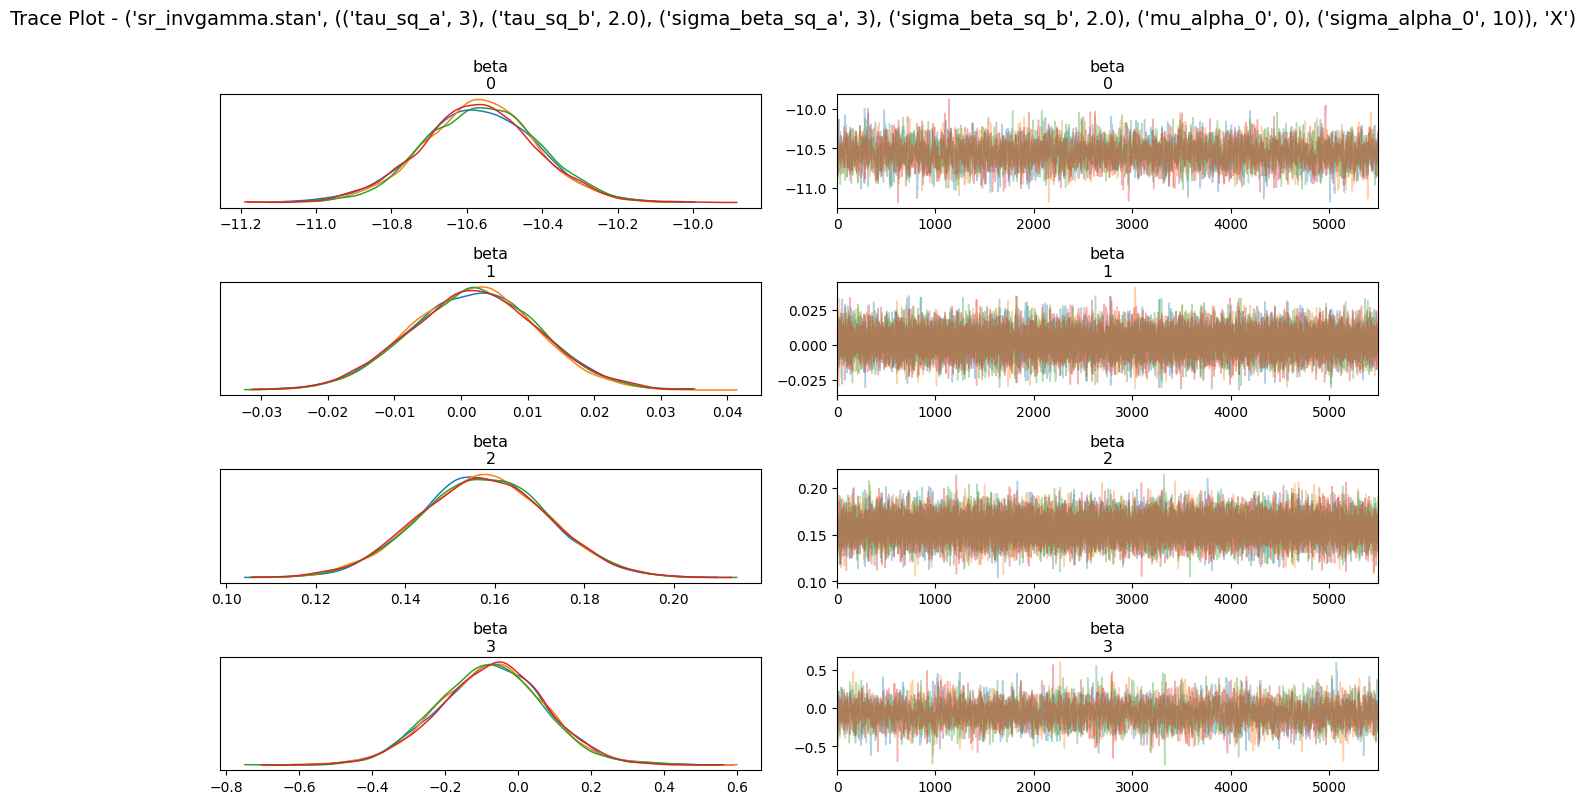

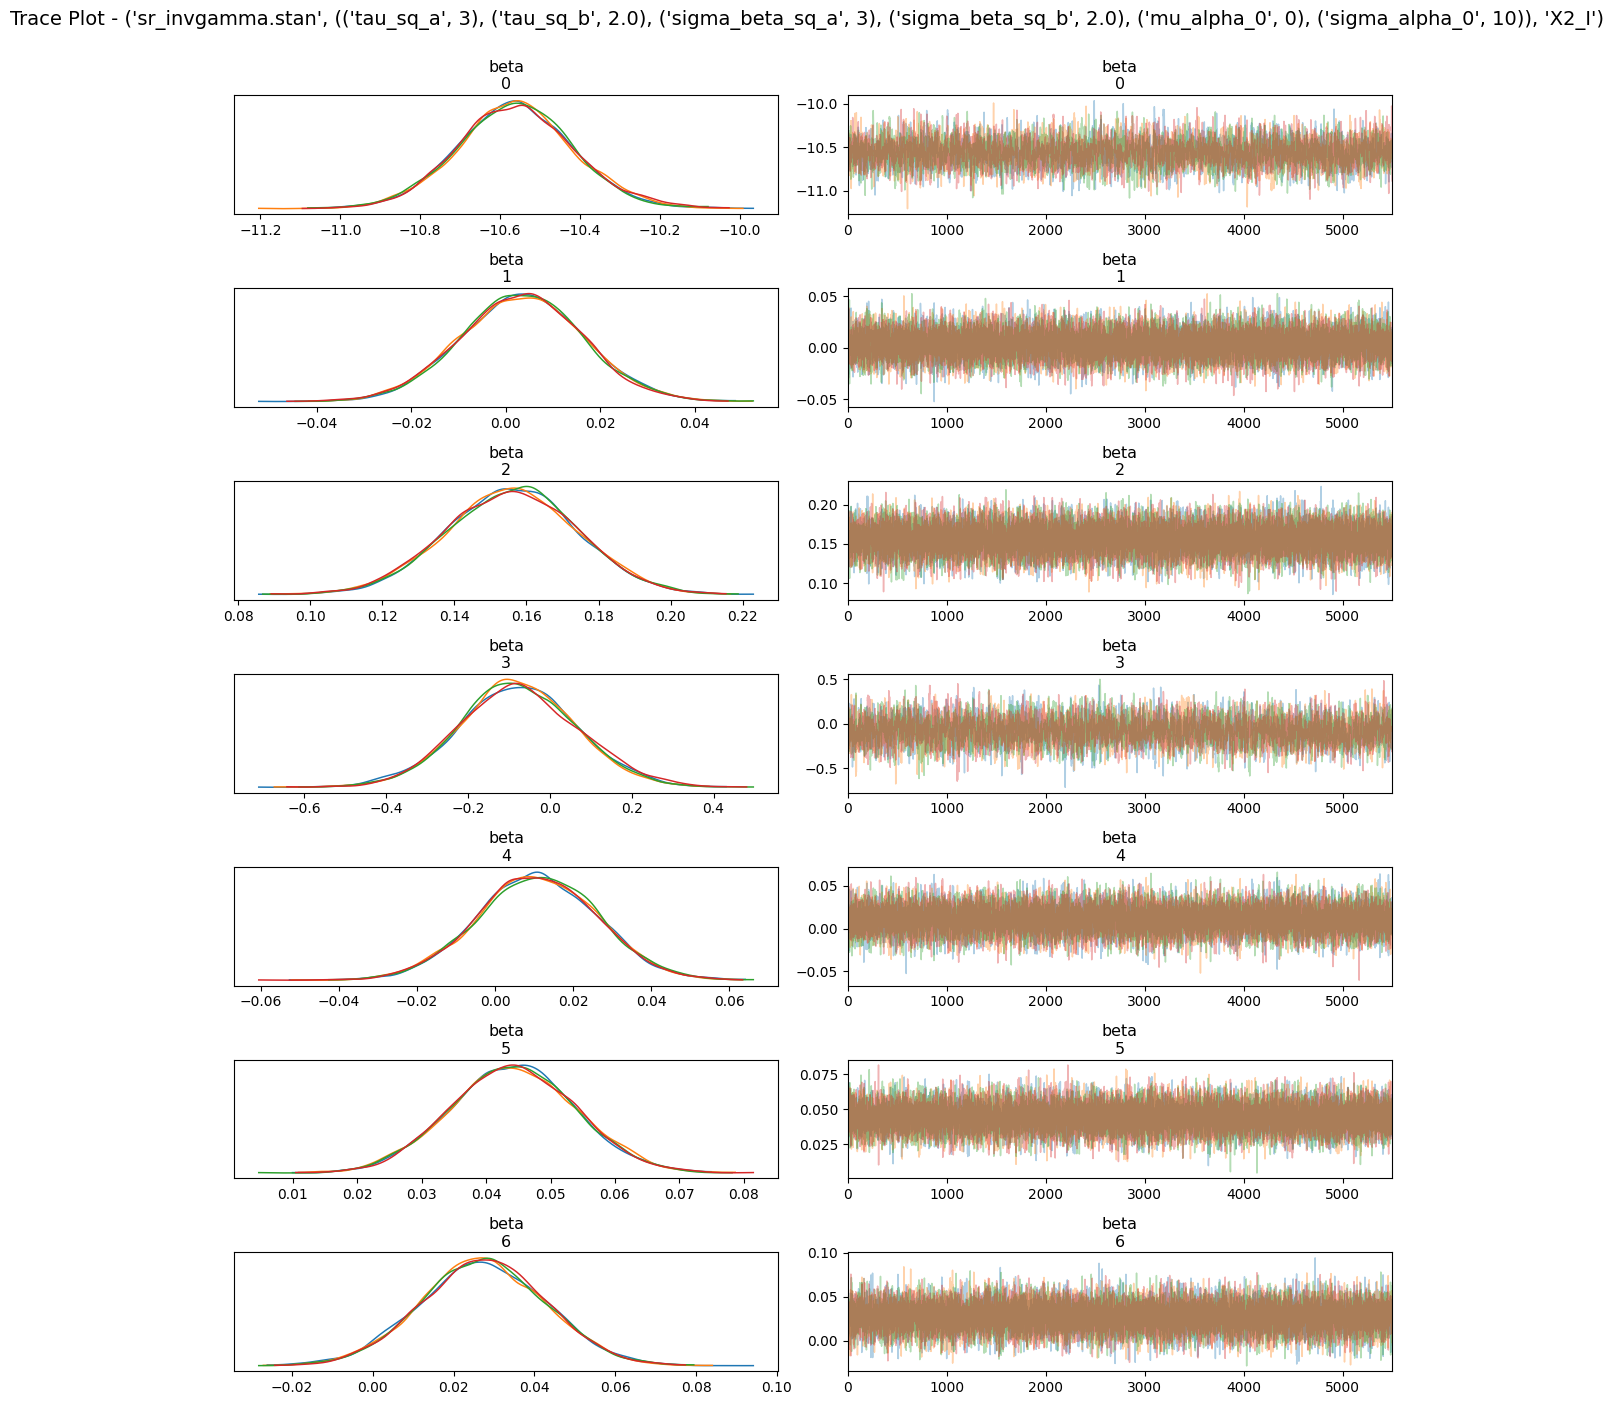

KeyError: 'az'

In [10]:
for key in models:
    poi_glm_data = models[key]["az"]
    az.plot_trace(poi_glm_data, var_names=["beta"], compact=False)
    plt.suptitle(f"Trace Plot - {key}", fontsize=14, y=1.0)
    plt.tight_layout()
    plt.show()

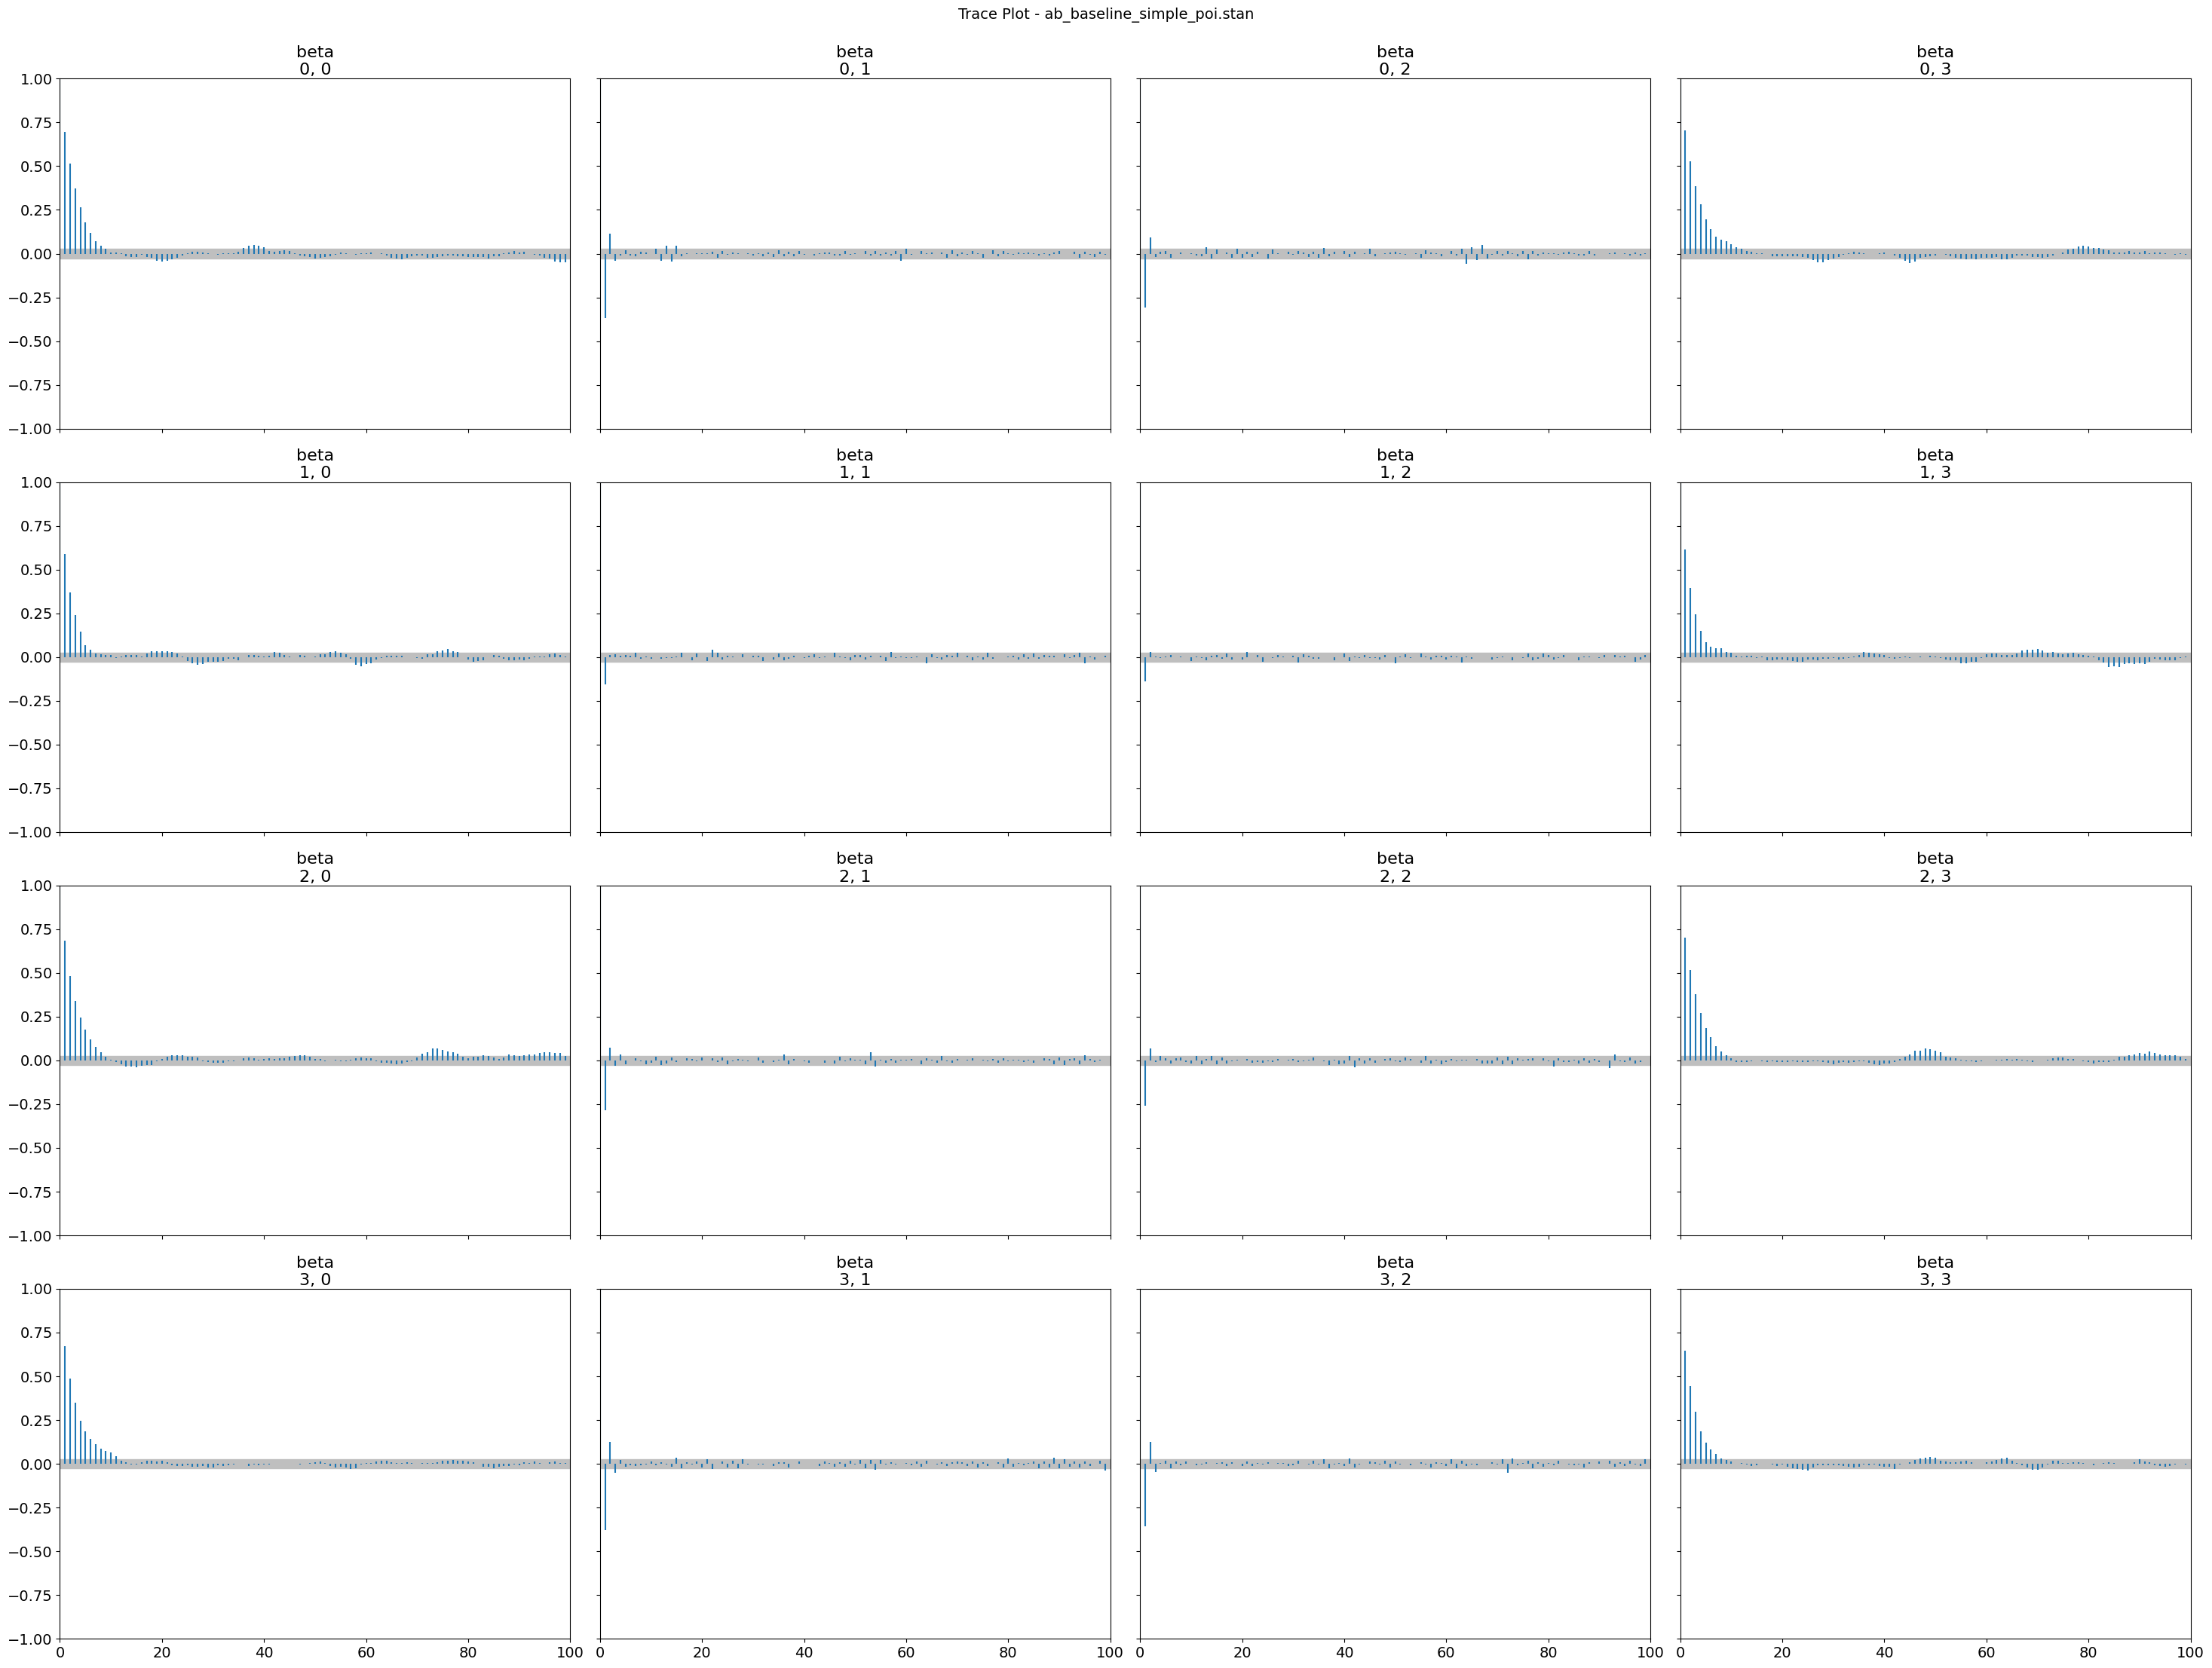

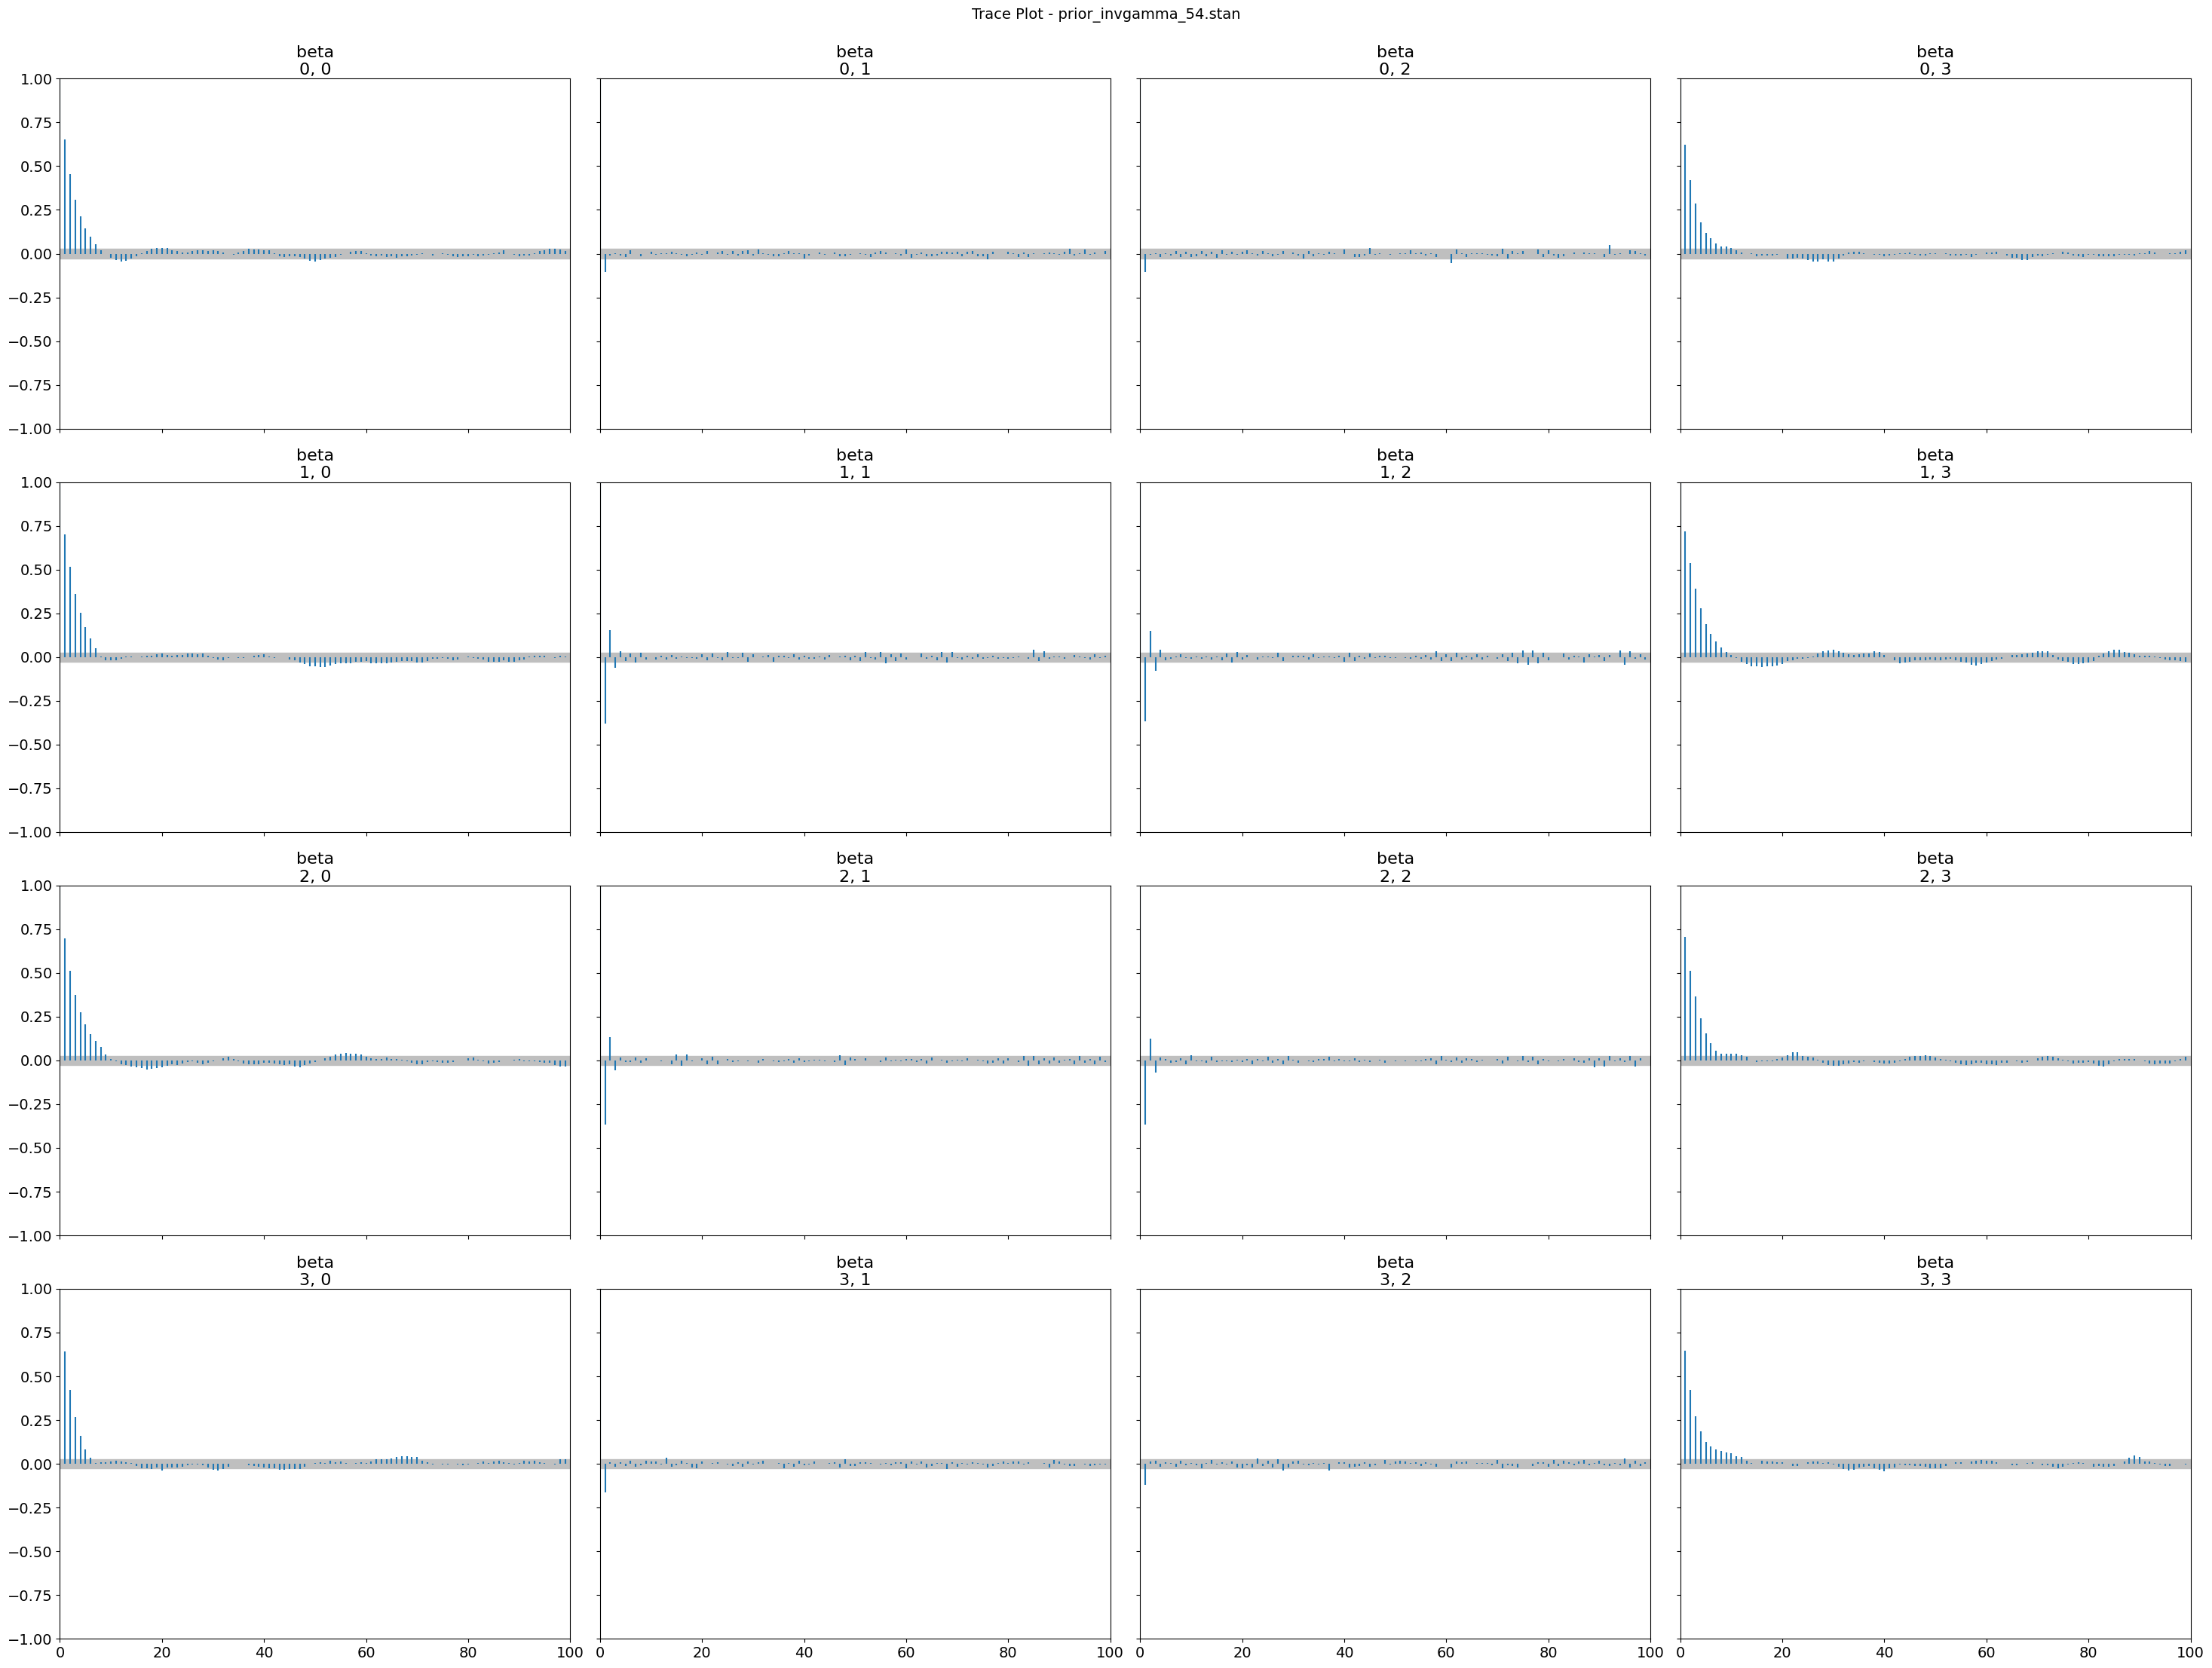

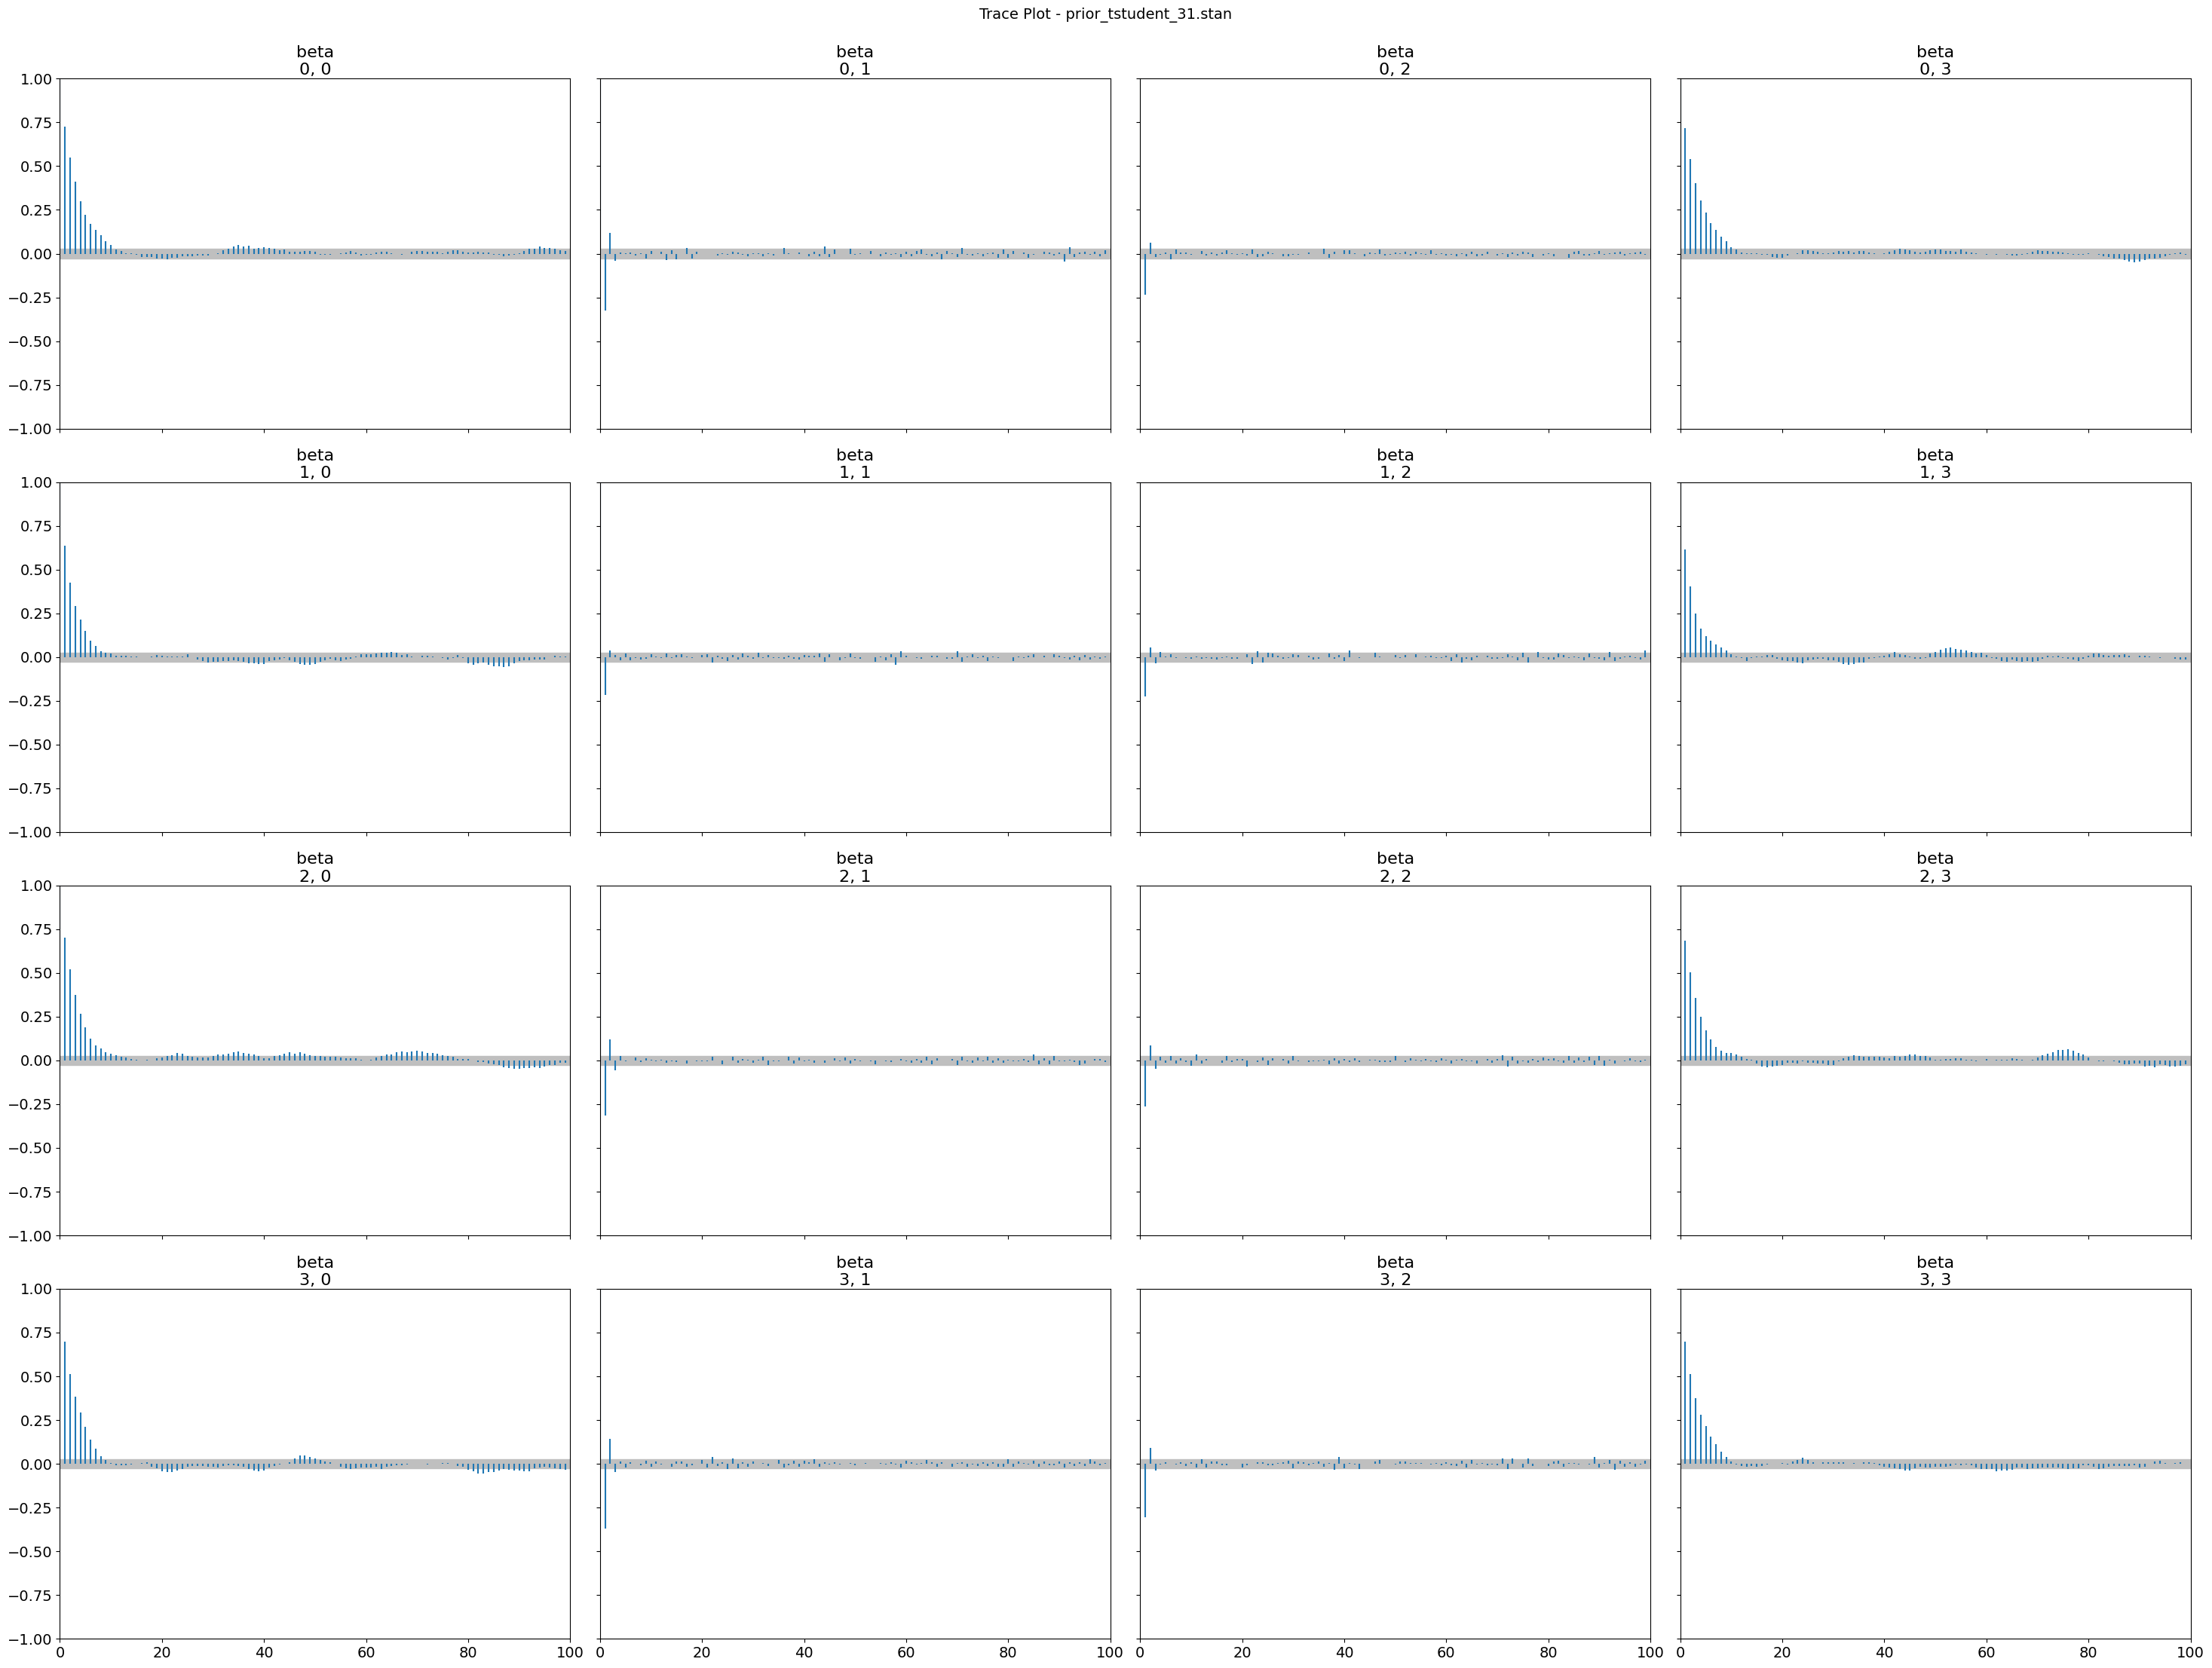

In [ ]:

for key in models:
    poi_glm_data = models[key]["az"]
    az.plot_autocorr(poi_glm_data, var_names=["beta"])
    plt.suptitle(f"Trace Plot - {key}", fontsize=14, y=1.0)
    plt.tight_layout()
    plt.show() 

In [ ]:
model_names = list(models.keys())
models[model_names[0]]["fit"].summary()

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,68878.900000,0.050640,4.516690,4.494500,68870.900000,68879.200000,68885.600000,8004.25,13679.10,4.88896,1.000180
beta[1],-10.564300,0.002179,0.140970,0.135332,-10.795000,-10.566600,-10.329800,4187.34,6507.97,2.55761,1.000670
beta[2],0.001957,0.000048,0.009706,0.009642,-0.014037,0.002024,0.017975,40730.60,15968.50,24.87810,0.999956
beta[3],0.157407,0.000078,0.014656,0.014616,0.133279,0.157433,0.181532,34977.20,13997.90,21.36390,1.000020
beta[4],-0.084316,0.002196,0.141234,0.136675,-0.315324,-0.083931,0.145152,4136.38,6372.09,2.52649,1.000760
...,...,...,...,...,...,...,...,...,...,...,...
log_lik[374],-2.544200,0.001001,0.139028,0.096933,-2.829010,-2.497350,-2.421780,21742.10,18134.80,13.28000,0.999923
log_lik[375],-3.200120,0.002645,0.398028,0.388297,-3.929880,-3.155170,-2.631000,22985.50,18047.20,14.03940,0.999910
log_lik[376],-2.180700,0.000978,0.148173,0.148244,-2.431650,-2.177690,-1.942000,22985.50,18047.20,14.03940,0.999906
log_lik[377],-1.403360,0.000531,0.080293,0.080190,-1.543080,-1.399430,-1.278280,22985.50,18047.20,14.03950,0.999907


In [ ]:
glm_fit = models[model_names[1]]["fit"]
glm_fit.summary()

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,68866.600000,0.051569,4.559570,4.527860,68858.600000,68866.900000,68873.500000,7831.63,11856.10,4.99774,1.00012
beta[1],-10.547500,0.002439,0.160378,0.157260,-10.809700,-10.547800,-10.285000,4337.56,6566.76,2.76801,1.00070
beta[2],0.001878,0.000050,0.009631,0.009526,-0.013892,0.001872,0.017675,37947.40,15545.00,24.21610,1.00016
beta[3],0.157966,0.000076,0.014404,0.014317,0.134383,0.157914,0.181723,35614.20,16315.80,22.72720,1.00041
beta[4],-0.081445,0.002538,0.161789,0.157388,-0.350443,-0.078827,0.181965,4070.24,6627.49,2.59742,1.00119
...,...,...,...,...,...,...,...,...,...,...,...
log_lik[374],-2.545420,0.001037,0.142181,0.097121,-2.836570,-2.496940,-2.421750,21754.70,17434.80,13.88280,1.00001
log_lik[375],-3.201070,0.002718,0.404155,0.392209,-3.944390,-3.152570,-2.626300,22292.60,17109.50,14.22600,1.00018
log_lik[376],-2.180690,0.001006,0.150184,0.150151,-2.435890,-2.176710,-1.939320,22292.60,17109.50,14.22600,1.00023
log_lik[377],-1.403420,0.000545,0.081423,0.081035,-1.545580,-1.398900,-1.276980,22292.60,17109.50,14.22600,1.00022


In [ ]:
glm_fit = models[model_names[2]]["fit"]
glm_fit.summary()

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,68869.900000,0.054130,4.522220,4.532310,68862.000000,68870.300000,68876.800000,7096.24,12120.40,6.07305,1.00065
beta[1],-10.568800,0.002254,0.138533,0.133822,-10.793300,-10.570100,-10.337800,3795.61,6213.46,3.24833,1.00108
beta[2],0.001925,0.000047,0.009578,0.009433,-0.013896,0.001866,0.017862,41315.90,15813.50,35.35860,1.00028
beta[3],0.157301,0.000075,0.014481,0.014365,0.133424,0.157286,0.181249,37424.70,15135.10,32.02850,1.00046
beta[4],-0.084588,0.002210,0.137300,0.133267,-0.306892,-0.085079,0.144370,3869.04,5830.05,3.31117,1.00124
...,...,...,...,...,...,...,...,...,...,...,...
log_lik[374],-2.543250,0.001034,0.138847,0.095752,-2.819160,-2.496040,-2.421770,21069.90,17411.20,18.03180,1.00048
log_lik[375],-3.196760,0.002674,0.397674,0.389221,-3.910610,-3.150310,-2.631250,22794.40,17518.50,19.50770,1.00048
log_lik[376],-2.179400,0.000982,0.148280,0.148522,-2.426000,-2.175860,-1.942140,22794.40,17518.50,19.50770,1.00047
log_lik[377],-1.402670,0.000533,0.080306,0.080282,-1.539760,-1.398430,-1.278350,22794.40,17518.50,19.50770,1.00048


In [19]:
az.plot_posterior(models[model_names[0]]["fit"], var_names=["beta"], hdi_prob=0.95)

TypeError: unhashable type: 'dict'

array([<Axes: title={'center': 'beta\n0'}>,
       <Axes: title={'center': 'beta\n1'}>,
       <Axes: title={'center': 'beta\n2'}>,
       <Axes: title={'center': 'beta\n3'}>], dtype=object)

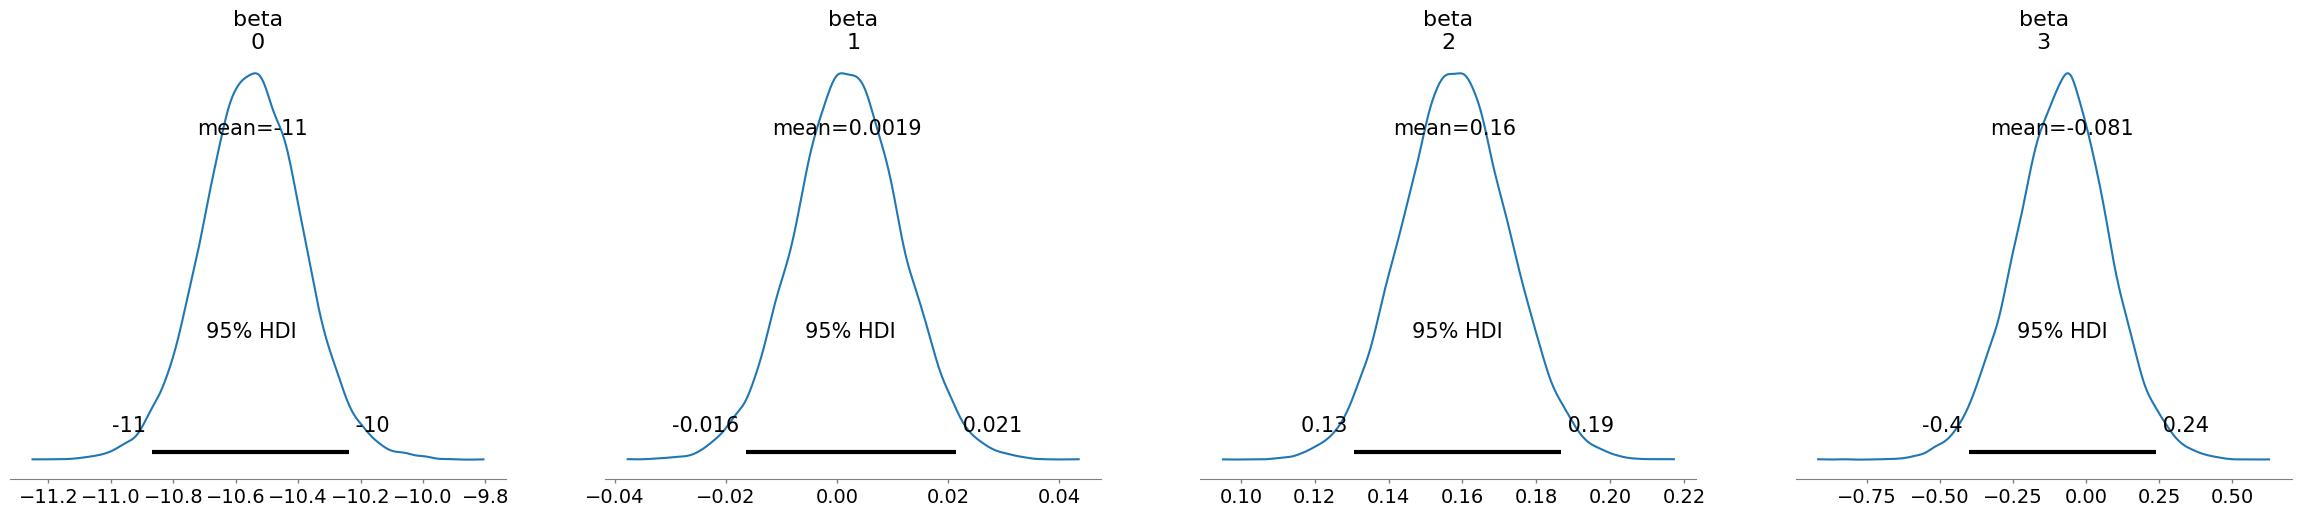

In [ ]:
az.plot_posterior(models[model_names[1]]["fit"], var_names=["beta"], hdi_prob=0.95)

array([<Axes: title={'center': 'beta\n0'}>,
       <Axes: title={'center': 'beta\n1'}>,
       <Axes: title={'center': 'beta\n2'}>,
       <Axes: title={'center': 'beta\n3'}>], dtype=object)

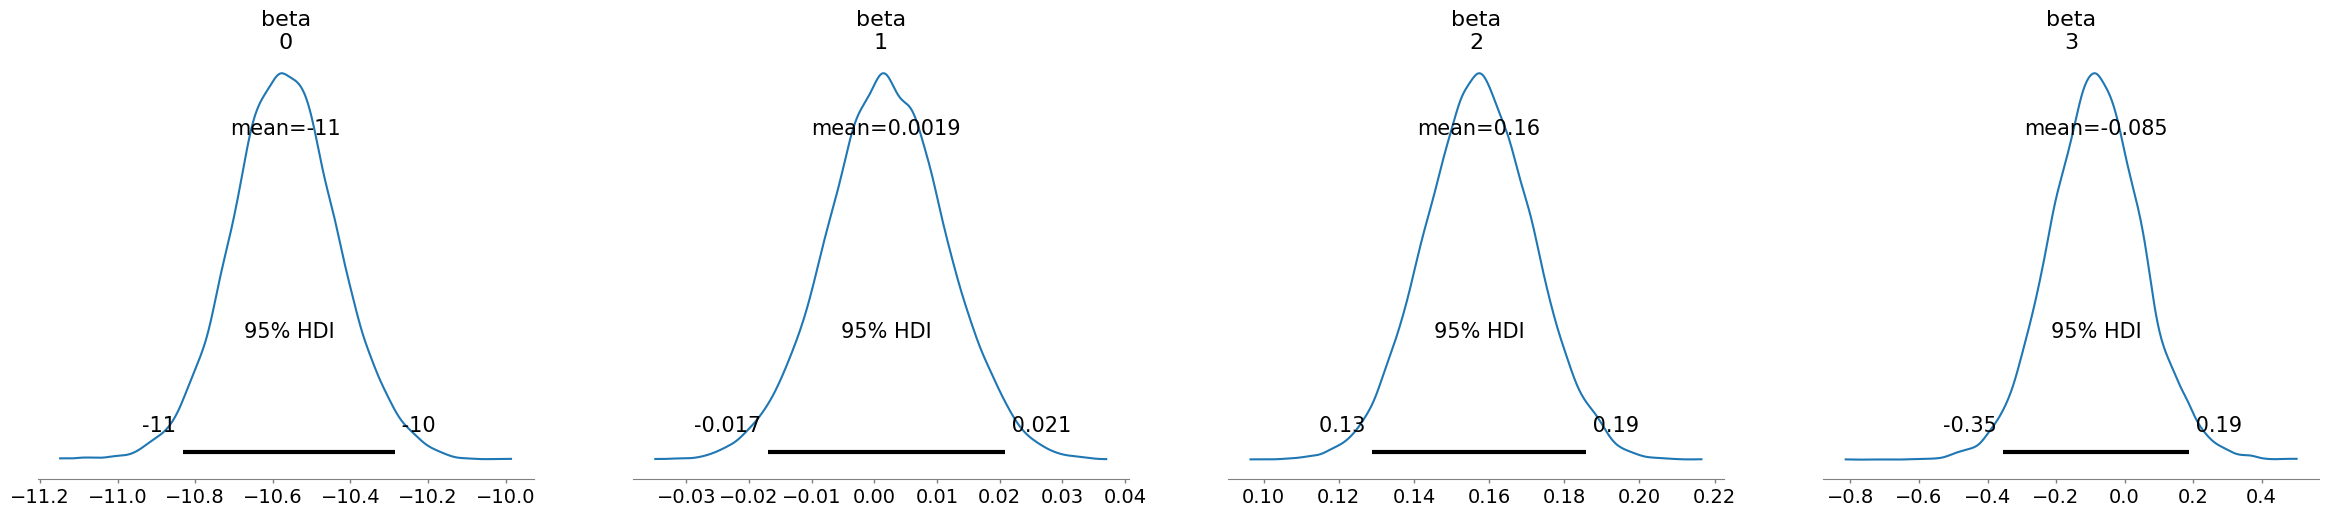

In [ ]:
az.plot_posterior(models[model_names[2]]["fit"], var_names=["beta"], hdi_prob=0.95)

In [12]:
def plot_confident_intervals(model_fit, az_data, var_name="beta", eps=0.1):
    
    # Summary with 95% HDI
    sum_beta = az.summary(model_fit, var_names=[var_name], hdi_prob=0.95)
    names = sum_beta.index.to_list()[1:]
    mean  = sum_beta["mean"].values[1:]
    low   = sum_beta["hdi_2.5%"].values[1:]
    high  = sum_beta["hdi_97.5%"].values[1:]
    y = np.arange(len(names))

    # Extract posterior samples
    samples = az_data.posterior[var_name].values
    # Shape: (chains, draws, p)
    samples = samples.reshape(-1, samples.shape[-1])  # (n_samples, p)

    colors = []

    # Assign colors based on posterior mass
    for j in range(samples.shape[1]):
        s = samples[:, j]

        p_neg  = np.mean(s < 0)
        p_pos  = np.mean(s > 0)
        p_zero = np.mean(np.abs(s) < eps)

        if p_neg > 0.5:
            colors.append("red")      # mostly negative effect
        elif p_pos > 0.5:
            colors.append("green")    # mostly positive effect
        elif p_zero > 0.4:
            colors.append("gray")     # mass concentrated near zero
        else:
            colors.append("gray")     # conservative fallback

    # Plot
    plt.figure(figsize=(6, 3))
    for i in range(len(names)):
        plt.plot([low[i], high[i]], [y[i], y[i]], lw=3, color=colors[i])
        plt.plot(mean[i], y[i], "o", color=colors[i])

    plt.axvline(0, color="black", ls="--", alpha=0.7)
    plt.yticks(y, names)
    plt.xlabel("Beta (log-scale effect)")
    plt.title("Posterior 95% HDI — Beta coefficients")
    plt.tight_layout()
    plt.show()



In [13]:
for i in model_names:
    print(i)
    plot_confident_intervals(models[i]["fit"], models[i]["az"],var_name="beta")

('sr_invgamma.stan', {'tau_sq_a': 3, 'tau_sq_b': 0.18, 'sigma_beta_sq_a': 3, 'sigma_beta_sq_b': 0.18, 'mu_alpha_0': 0, 'sigma_alpha_0': 5})


TypeError: unhashable type: 'dict'

plot: ('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 0.18), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 0.18), ('mu_alpha_0', 0), ('sigma_alpha_0', 5)), 'X')


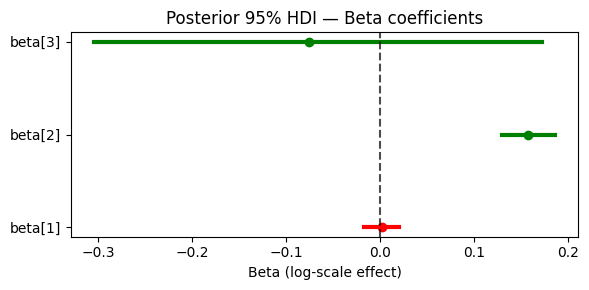

plot: ('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 0.18), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 0.18), ('mu_alpha_0', 0), ('sigma_alpha_0', 5)), 'X2_I')


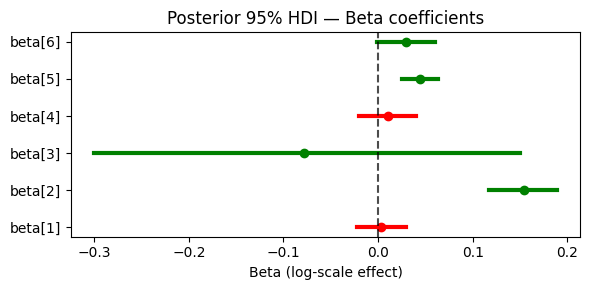

plot: ('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 0.18), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 0.18), ('mu_alpha_0', 0), ('sigma_alpha_0', 10)), 'X')


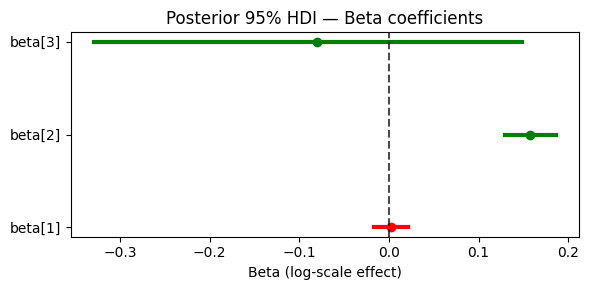

plot: ('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 0.18), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 0.18), ('mu_alpha_0', 0), ('sigma_alpha_0', 10)), 'X2_I')


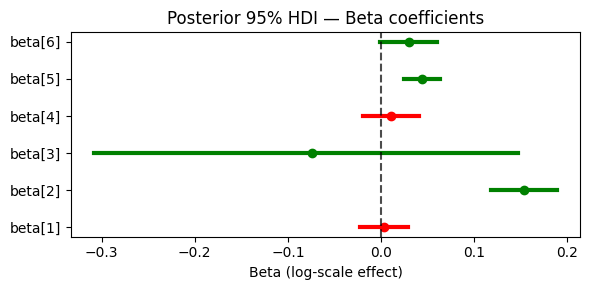

plot: ('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 0.72), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 0.72), ('mu_alpha_0', 0), ('sigma_alpha_0', 5)), 'X')


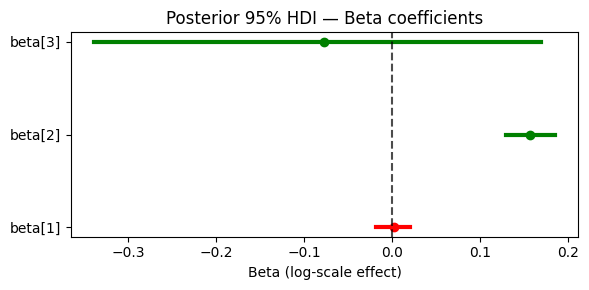

plot: ('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 0.72), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 0.72), ('mu_alpha_0', 0), ('sigma_alpha_0', 5)), 'X2_I')


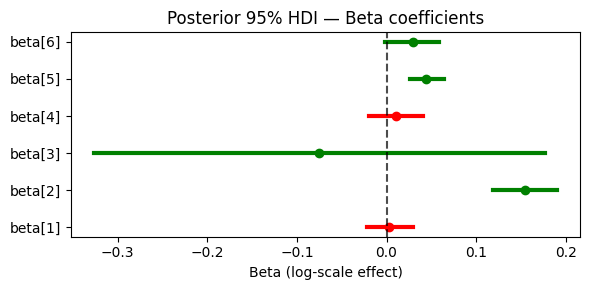

plot: ('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 0.72), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 0.72), ('mu_alpha_0', 0), ('sigma_alpha_0', 10)), 'X')


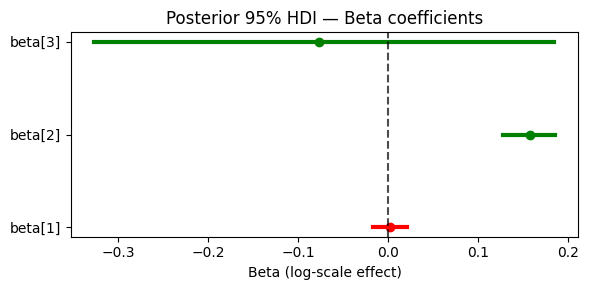

plot: ('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 0.72), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 0.72), ('mu_alpha_0', 0), ('sigma_alpha_0', 10)), 'X2_I')


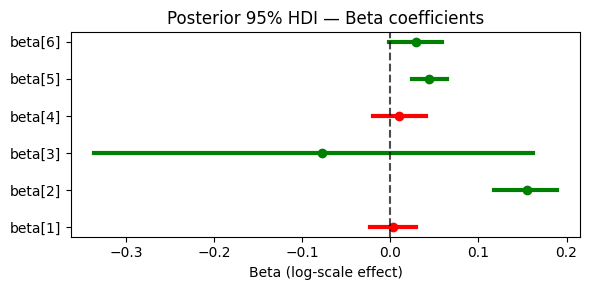

plot: ('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 2.0), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 2.0), ('mu_alpha_0', 0), ('sigma_alpha_0', 5)), 'X')


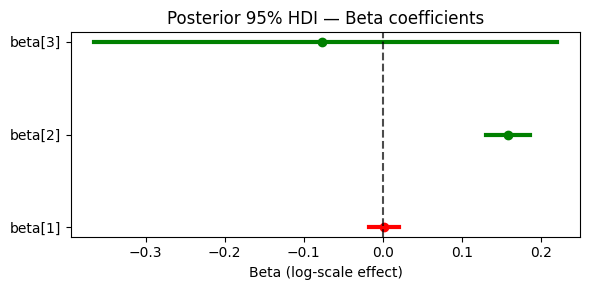

plot: ('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 2.0), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 2.0), ('mu_alpha_0', 0), ('sigma_alpha_0', 5)), 'X2_I')


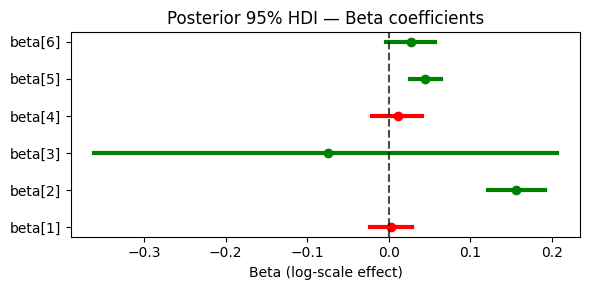

plot: ('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 2.0), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 2.0), ('mu_alpha_0', 0), ('sigma_alpha_0', 10)), 'X')


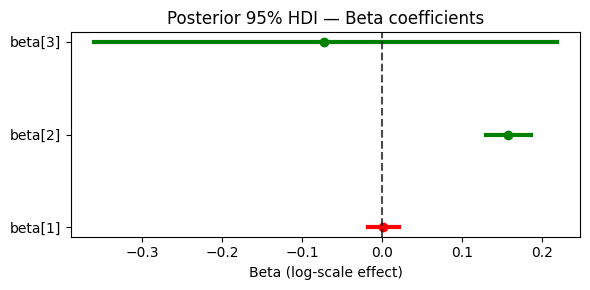

plot: ('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 2.0), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 2.0), ('mu_alpha_0', 0), ('sigma_alpha_0', 10)), 'X2_I')


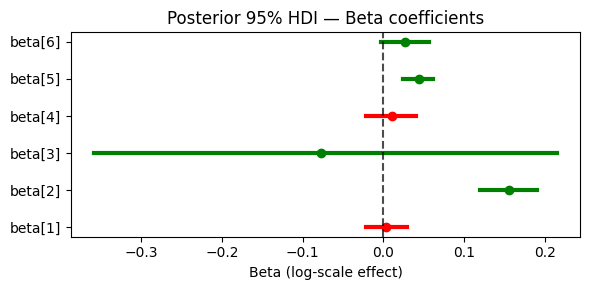

skip: ('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 0.08), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 0.08), ('mu_alpha_0', 0), ('sigma_alpha_0', 5)), 'X')
skip: ('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 0.08), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 0.08), ('mu_alpha_0', 0), ('sigma_alpha_0', 5)), 'X2_I')
skip: ('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 0.08), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 0.08), ('mu_alpha_0', 0), ('sigma_alpha_0', 10)), 'X')
skip: ('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 0.08), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 0.08), ('mu_alpha_0', 0), ('sigma_alpha_0', 10)), 'X2_I')
skip: ('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 4.5), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 4.5), ('mu_alpha_0', 0), ('sigma_alpha_0', 5)), 'X')
skip: ('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 4.5), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 4.5), ('mu_alpha_0', 0), ('sigma_alpha_0', 5)), 'X2_I')
skip: ('sr_invg

In [18]:
for key, obj in models.items():
    if isinstance(obj, dict) and "az" in obj:
        print("plot:", key)
        plot_confident_intervals(
            obj["az"],      # al posto di obj["fit"]
            obj["az"],      # az_data
            var_name="beta"
        )
    else:
        print("skip:", key)



In [14]:
for key, obj in models.items():
    print(key)
    plot_confident_intervals(obj["fit"], obj["az"], var_name="beta")


('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 0.18), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 0.18), ('mu_alpha_0', 0), ('sigma_alpha_0', 5)), 'X')


KeyError: 'fit'

### Compare Models 

In [20]:
compare_dict = {
}
for key in models:
    compare_dict[key] = models[key]["az"]

comparison_loo = az.compare(compare_dict, ic="loo")
print("\n=== LOO COMPARISON ===")
print(comparison_loo)

az.plot_compare(comparison_loo, insample_dev=False)
plt.tight_layout()
plt.show()


KeyError: 'az'

In [22]:
compare_dict = {}

for key, obj in models.items():
    if isinstance(obj, dict) and ("az" in obj) and (obj["az"] is not None):
        compare_dict[key] = obj["az"]

print(f"Included {len(compare_dict)} models with 'az' out of {len(models)} total.")

comparison_loo = az.compare(compare_dict, ic="loo")
print("\n=== LOO COMPARISON ===")
print(comparison_loo)

az.plot_compare(comparison_loo, insample_dev=False)
plt.tight_layout()
plt.show()


Included 12 models with 'az' out of 36 total.


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Libra

KeyError: "None of [Index([                                                                                                               'sr_invgamma.stan',\n       (('tau_sq_a', 3), ('tau_sq_b', 0.18), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 0.18), ('mu_alpha_0', 0), ('sigma_alpha_0', 5)),\n                                                                                                                                  'X2_I'],\n      dtype='object')] are in the [index]"

In [21]:
comparison_waic = az.compare(compare_dict, ic="waic")
print("\n=== WAIC COMPARISON ===")
print(comparison_waic)

az.plot_compare(comparison_waic, insample_dev=False)
plt.tight_layout()
plt.show()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/arviz/stats/stats.py:1667: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/arviz/stats/stats.py:1667: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/arviz/stats/stats.py:1667: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
/Library/Fram

KeyError: "None of [Index([                                                                                                                'sr_invgamma.stan',\n       (('tau_sq_a', 3), ('tau_sq_b', 0.18), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 0.18), ('mu_alpha_0', 0), ('sigma_alpha_0', 10)),\n                                                                                                                                   'X2_I'],\n      dtype='object')] are in the [index]"

In [ ]:
import numpy as np
import pandas as pd

def select_by_hdi(az_data, var_name="beta", credible_mass=0.95, 
                  covariate_names=["Intercept", "IBU", "DMSO", "Temp"]):
    summary = az.summary(az_data, var_names=[var_name], 
                        hdi_prob=credible_mass)
    
    results = []
    for idx, name in enumerate(covariate_names):
        row = summary.iloc[idx]
        hdi_low = row[f"hdi_{(1-credible_mass)/2*100:.1f}%"]
        hdi_high = row[f"hdi_{(1+credible_mass)/2*100:.1f}%"]
        
        crosses_zero = (hdi_low < 0) and (hdi_high > 0)
        
        results.append({
            'variable': name,
            'mean': row['mean'],
            'hdi_low': hdi_low,
            'hdi_high': hdi_high,
            'crosses_zero': crosses_zero,
            'selected': not crosses_zero
        })
    
    return pd.DataFrame(results)

print("=" * 40)
print("HDI-BASED SELECTION (95% credible intervals)")
print("=" * 40)

for model_name in model_names:
    print(f"\n{model_name}:")
    result = select_by_hdi(az_data=models[model_name]["az"], credible_mass=0.95)
    # print(result)
    print(f"Selected: {result[result['selected']]['variable'].tolist()}")

HDI-BASED SELECTION (95% credible intervals)

ab_baseline_simple_poi.stan:
Selected: ['Intercept', 'DMSO']

prior_invgamma_54.stan:
Selected: ['Intercept', 'DMSO']

prior_tstudent_31.stan:
Selected: ['Intercept', 'DMSO']


In [ ]:
def posterior_inclusion_probability(az_data, var_name="beta", 
                                   threshold=None,
                                   covariate_names=["Intercept", "IBU", "DMSO", "Temp"], prob=0.5):
    """
    Calculate P(|beta_j| > threshold | data)
    
    If threshold is None, uses practical significance = 0.1 * posterior SD for each variable
    (Rule of thumb: effects smaller than 10% of SD are negligible)
    """
    samples = az_data.posterior[var_name].values
    n_chains, n_draws, p = samples.shape
    
    results = []
    for j in range(p):
        beta_j = samples[:, :, j].flatten()
        
        if threshold is None:
            thresh = 0.1 * np.std(beta_j)
        else:
            thresh = threshold
        
        pip = np.mean(np.abs(beta_j) > thresh)
        
        prob_positive = np.mean(beta_j > thresh)
        prob_negative = np.mean(beta_j < -thresh)
        
        results.append({
            'variable': covariate_names[j],
            'threshold_used': thresh,
            'PIP': pip,
            'P(β > thresh)': prob_positive,
            'P(β < -thresh)': prob_negative,
            'median': np.median(beta_j),
            'sd': np.std(beta_j),
            'selected': pip > prob  
        })
    
    return pd.DataFrame(results)

print("\n" + "=" * 60)
print("POSTERIOR INCLUSION PROBABILITY")
print("=" * 60)

for model_name in model_names:
    print(f"\n{model_name}:")
    print("\n--- Auto threshold (10% of posterior SD) ---")
    result = posterior_inclusion_probability(az_data=models[model_name]["az"], prob=0.8)
    #print(result[['variable', 'threshold_used', 'PIP', 'median', 'sd', 'selected']])
    print(f"Selected (PIP > 0.8): {result[result['selected']]['variable'].tolist()}")
    
    print("\n--- Fixed threshold = 0.1 (practical significance) ---")
    result_fixed = posterior_inclusion_probability(
        models[model_name]["az"],
        threshold=0.1, prob=0.8
    )
    #print(result_fixed[['variable', 'PIP', 'median', 'selected']])
    print(f"Selected: {result_fixed[result_fixed['selected']]['variable'].tolist()}")


POSTERIOR INCLUSION PROBABILITY

ab_baseline_simple_poi.stan:

--- Auto threshold (10% of posterior SD) ---
Selected (PIP > 0.8): ['Intercept', 'IBU', 'DMSO', 'Temp']

--- Fixed threshold = 0.1 (practical significance) ---
Selected: ['Intercept', 'DMSO']

prior_invgamma_54.stan:

--- Auto threshold (10% of posterior SD) ---
Selected (PIP > 0.8): ['Intercept', 'IBU', 'DMSO', 'Temp']

--- Fixed threshold = 0.1 (practical significance) ---
Selected: ['Intercept', 'DMSO']

prior_tstudent_31.stan:

--- Auto threshold (10% of posterior SD) ---
Selected (PIP > 0.8): ['Intercept', 'IBU', 'DMSO', 'Temp']

--- Fixed threshold = 0.1 (practical significance) ---
Selected: ['Intercept', 'DMSO']


In [ ]:
def cross_model_selection(models_dict, model_names, 
                         covariate_names=["Intercept", "IBU", "DMSO", "Temp"],
                         methods=['hdi', 'pip'], pip_th = None, pip_prob=0.5):
    """
    Variable selected if chosen by majority of models
    """
    selection_matrix = []
    
    for model_name in model_names:
        for method in methods:
            if method == 'hdi':
                result = select_by_hdi(models_dict[model_name]["az"], 
                                      covariate_names=covariate_names)
            if method == 'pip':
                result = posterior_inclusion_probability(
        models_dict[model_name]["az"],
        threshold=pip_th, prob=pip_prob
    )   
            selection_matrix.append(result['selected'].values)
    
    selection_matrix = np.array(selection_matrix)
    
    selection_count = selection_matrix.sum(axis=0)
    
    consensus_df = pd.DataFrame({
        'variable': covariate_names,
        'n_models_selected': selection_count,
        'proportion': selection_count / (len(model_names) * len(methods)),
        'consensus_selected': selection_count >= (len(model_names) * len(methods) / 2)
    })
    
    return consensus_df

working_models = model_names

print("\n" + "=" * 60)
print("CROSS-MODEL CONSENSUS")
print("=" * 60)


CROSS-MODEL CONSENSUS


In [ ]:
consensus = cross_model_selection(models, working_models, methods=['hdi', 'pip'], pip_prob=0.5, pip_th=0.05)
print(consensus)
print(f"\nFinal selection: {consensus[consensus['consensus_selected']]['variable'].tolist()}")

    variable  n_models_selected  proportion  consensus_selected
0  Intercept                 14    1.000000                True
1        IBU                  0    0.000000               False
2       DMSO                 14    1.000000                True
3       Temp                  5    0.357143               False

Final selection: ['Intercept', 'DMSO']


In [ ]:
consensus = cross_model_selection(models, working_models, methods=['hdi'])
print(consensus)
print(f"\nFinal selection: {consensus[consensus['consensus_selected']]['variable'].tolist()}")

    variable  n_models_selected  proportion  consensus_selected
0  Intercept                  7         1.0                True
1        IBU                  0         0.0               False
2       DMSO                  7         1.0                True
3       Temp                  0         0.0               False

Final selection: ['Intercept', 'DMSO']


In [ ]:
consensus = cross_model_selection(models, working_models, methods=['pip'], pip_prob=0.8)
print(consensus)
print(f"\nFinal selection: {consensus[consensus['consensus_selected']]['variable'].tolist()}")

    variable  n_models_selected  proportion  consensus_selected
0  Intercept                  7         1.0                True
1        IBU                  7         1.0                True
2       DMSO                  7         1.0                True
3       Temp                  7         1.0                True

Final selection: ['Intercept', 'IBU', 'DMSO', 'Temp']


In [ ]:
consensus = cross_model_selection(models, working_models, methods=['pip'], pip_prob=0.8, pip_th=0.1)
print(consensus)
print(f"\nFinal selection: {consensus[consensus['consensus_selected']]['variable'].tolist()}")

    variable  n_models_selected  proportion  consensus_selected
0  Intercept                  7         1.0                True
1        IBU                  0         0.0               False
2       DMSO                  7         1.0                True
3       Temp                  0         0.0               False

Final selection: ['Intercept', 'DMSO']


In [ ]:
consensus = cross_model_selection(models, working_models, methods=['pip'], pip_prob=0.5, pip_th=0.05)
print(consensus)
print(f"\nFinal selection: {consensus[consensus['consensus_selected']]['variable'].tolist()}")

    variable  n_models_selected  proportion  consensus_selected
0  Intercept                  7    1.000000                True
1        IBU                  0    0.000000               False
2       DMSO                  7    1.000000                True
3       Temp                  5    0.714286                True

Final selection: ['Intercept', 'DMSO', 'Temp']


# comparison_loo 
very expensive -> I need to fit the sample with removing each covariate -> does not make sense. I will include only two covariate to see which one is better (TEMP, DMSO)